# PYTHIA  vs HERWIG 

Full sample shape: (479068, 6)
Signal region shape: (85625, 6)


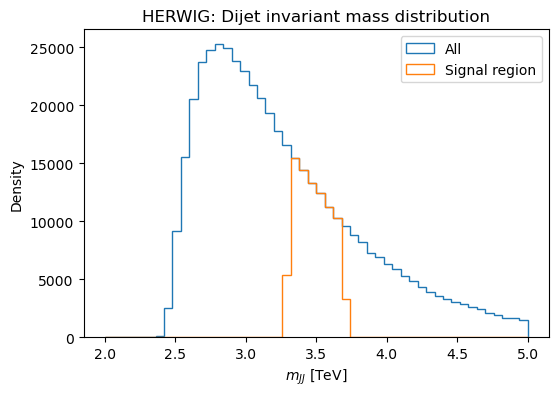

In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

def build_cathode_features_from_h5(h5_path, label=0):
    """
    Build the six-dimensional CATHODE feature array from your HDF5 features.

    Features:
        0: mJJ (TeV)
        1: m_min (TeV)
        2: Δm_J = m_max - m_min (TeV)
        3: tau21_min  (τ21 of lighter jet)
        4: tau21_max  (τ21 of heavier jet)
        5: label (0=background, 1=signal)
    """

    with h5py.File(h5_path, "r") as f:
        mJJ        = np.array(f["/mJJ"])[:, 0]          # shape (N,)
        jet_mass   = np.array(f["/jet_mass"])           # shape (N,2)
        tau21_beta1 = np.array(f["/beta1/ratios"])[:,:,0]  # τ21 = τ2/τ1 for β=1
        tau21_j1 = tau21_beta1[:,0]
        tau21_j2 = tau21_beta1[:,1]

    mJ1, mJ2 = jet_mass[:,0], jet_mass[:,1]

    # --- reorder by jet mass
    is_m1_smaller = mJ1 < mJ2
    m_min = np.where(is_m1_smaller, mJ1, mJ2)
    m_max = np.where(is_m1_smaller, mJ2, mJ1)
    d_mJ  = m_max - m_min

    # reorder tau21 in same order as masses
    tau21_min = np.where(is_m1_smaller, tau21_j1, tau21_j2)
    tau21_max = np.where(is_m1_smaller, tau21_j2, tau21_j1)

    # --- convert GeV → TeV
    out = np.column_stack((
        mJJ/1000.,
        m_min/1000.,
        d_mJ/1000.,
        tau21_min,
        tau21_max,
        np.full_like(mJJ, label)
    ))
    return out


def select_signal_region(features):
    """Apply the CATHODE signal region: 3.3 < mJJ < 3.7 TeV."""
    mask = (features[:,0] > 3.3) & (features[:,0] < 3.7)
    return features[mask]

# Example usage
# fn = "/data/ascaffid/LHC_Olympics/EagleEye/examples/LHC_checks/fastjet/extern/fastjet-contrib/Nsubjettiness/tau_bb2_CATH_features.h5"
fn = "/data/ascaffid/LHC_Olympics/EagleEye/examples/LHC_checks/fastjet/extern/fastjet-contrib/Nsubjettiness/bbox_2_cath_featrues_pre_reorder.h5"
features  = build_cathode_features_from_h5(fn, label=0)
Herwig_SR = select_signal_region(features)



# # Remove all rows with NaNs from Herwig_SR
Herwig_SR = Herwig_SR[~np.isnan(Herwig_SR).any(axis=1)]
features_SR = Herwig_SR  # update features_SR to match cleaned Herwig_SR
features = features[~np.isnan(features).any(axis=1)]
print("Full sample shape:", features.shape)
print("Signal region shape:", features_SR.shape)

# Quick diagnostic plots
plt.figure(figsize=(6,4))
plt.hist(features[:,0], bins=50, range=(2,5), histtype="step", label="All", density=False)
plt.hist(Herwig_SR[:,0], bins=50, range=(2,5), histtype="step", label="Signal region", density=False)
plt.xlabel(r"$m_{JJ}$ [TeV]")
plt.ylabel("Density")
plt.legend()
plt.title("HERWIG: Dijet invariant mass distribution")
plt.show()



Full sample shape: (487131, 6)
Signal region shape: (86366, 6)


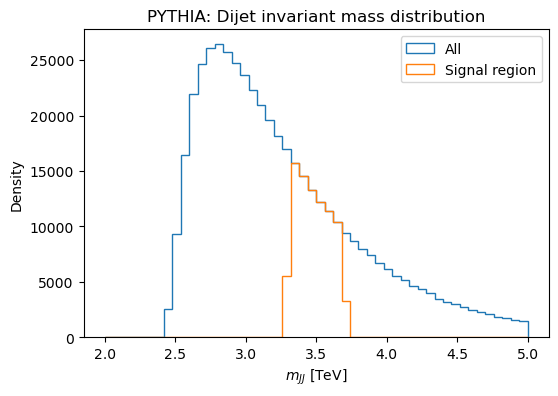

In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt


# Example usage
# fn = "/data/ascaffid/LHC_Olympics/EagleEye/examples/LHC_checks/fastjet/extern/fastjet-contrib/Nsubjettiness/tau_bb2_CATH_features.h5"
fn = "/data/ascaffid/LHC_Olympics/EagleEye/examples/LHC_checks/fastjet/extern/fastjet-contrib/Nsubjettiness/PYTHIA_cath_featrues_pre_reorder.h5"
features  = build_cathode_features_from_h5(fn, label=0)
PYTHIA_SR = select_signal_region(features)



# # Remove all rows with NaNs from Herwig_SR
PYTHIA_SR = PYTHIA_SR[~np.isnan(PYTHIA_SR).any(axis=1)]
features_SR = PYTHIA_SR  # update features_SR to match cleaned Herwig_SR
features = features[~np.isnan(features).any(axis=1)]
print("Full sample shape:", features.shape)
print("Signal region shape:", features_SR.shape)

# Quick diagnostic plots
plt.figure(figsize=(6,4))
plt.hist(features[:,0], bins=50, range=(2,5), histtype="step", label="All", density=False)
plt.hist(PYTHIA_SR[:,0], bins=50, range=(2,5), histtype="step", label="Signal region", density=False)
plt.xlabel(r"$m_{JJ}$ [TeV]")
plt.ylabel("Density")
plt.legend()
plt.title("PYTHIA: Dijet invariant mass distribution")
plt.show()



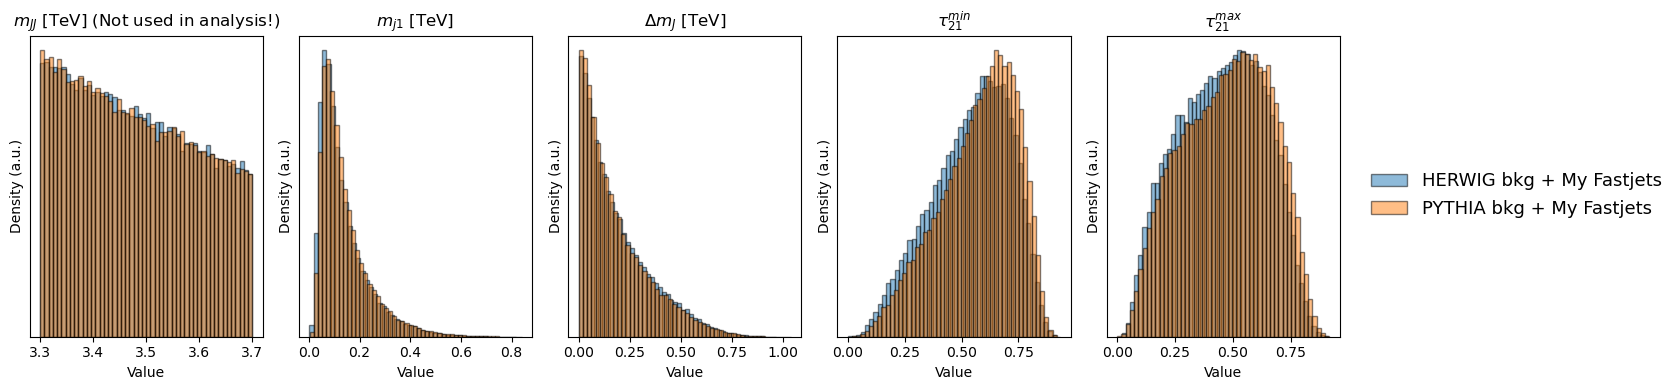

In [ ]:


def plot_feature_distributions_cath_samples(inner_mix_samples, inner_ref_samples, feature_names):
    """
    Plots the distributions of the 4 features in inner_mix_samples and inner_ref_samples,
    with a single legend placed outside the plots.
    """
    num_features = inner_mix_samples.shape[1]
    fig, axes = plt.subplots(1, num_features, figsize=(16, 4), sharey=False)
    if num_features == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        ax.hist(inner_ref_samples[:, i], bins=50, alpha=0.5, label='HERWIG bkg + My Fastjets', density=True, edgecolor='black')
        ax.hist(inner_mix_samples[:, i], bins=50, alpha=0.5, label='PYTHIA bkg + My Fastjets', density=True, edgecolor='black')
        ax.set_title(feature_names[i])
        ax.set_xlabel('Value')
        ax.set_ylabel('Density (a.u.)')
        ax.set_yticks([])

    # Create a single legend outside the subplots
    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.85, 0.5), fontsize=13, frameon=False)

    # Leave room on the right for the legend
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    # plt.savefig('/data/ascaffid/LHC_Olympics/EagleEye/examples/LHC_checks/dist_comp_myFJBB2_vs_official.png', dpi=300)
    plt.show()
# Call the function with appropriate arguments
plot_feature_distributions_cath_samples(
    PYTHIA_SR[:,0:5],   
    Herwig_SR[:, 0:5],
    feature_names=[
        r"$m_{JJ}$ [TeV] (Not used in analysis!)",
        r"$m_{j1}$ [TeV]",
        r"$\Delta m_J$ [TeV]",
        r"$\tau_{21}^{min}$",
        r"$\tau_{21}^{max}$",
        
    ]
)


In [ ]:
import sys
sys.path.append('../../eagleeye')
import EagleEye as EagleEye
import utils_EE 
import importlib
importlib.reload(EagleEye)
from utils_EE import compute_the_null
Upsilon_star_plus                 = 12
KM                                = 1000
p_ext                             = 1e-5
# Setting the Herwig background as the nominal background (our reference set)
Herwig_SR = Herwig_SR[:50000]
PYTHIA_SR = PYTHIA_SR[:50000]
p                                 = Herwig_SR.shape[0] / (Herwig_SR.shape[0] + PYTHIA_SR[:,1:5].shape[0])
res,_                             = EagleEye.Soar(PYTHIA_SR[:,1:5], Herwig_SR[:,1:5], result_dict_in = {}, K_M = KM,n_jobs=20,p_ext=p_ext,stats_null=compute_the_null(p=p, K_M=KM,N=50000),do_IDE=True)
# res,_                             = EagleEye.Soar(PYTHIA_SR[:,1:5], Herwig_SR[:,1:5], result_dict_in = {}, K_M = KM,n_jobs=20,p_ext=1e-5,stats_null={p:[Upsilon_star_plus],1-p:[Upsilon_star_plus]},do_IDE=True)

print("p = ", p)
print("Upsilon_star_plus = ", Upsilon_star_plus)

-----------------------------------------------------------------
Eagle...Soar!
-----------------------------------------------------------------
Compute the nearest neighbours
KNN completed: 0.00 %
KNN completed: 16.67 %
KNN completed: 33.33 %
KNN completed: 50.00 %
KNN completed: 66.67 %
KNN completed: 83.33 %
-----------------------------------------------------------------
Flagging of putative anomalous points
-----------------------------------------------------------------


<IPython.core.display.Math object>

'DONE!'

<IPython.core.display.Math object>

'DONE!'

...

<IPython.core.display.Math object>

'DONE!'

<IPython.core.display.Math object>

'DONE!'

p =  0.5
Upsilon_star_plus =  12


In [ ]:
from utils_EE import compute_the_null
stats_null_up                     = compute_the_null(p, KM,N=50000)

In [ ]:
import sys
sys.path.append('../../eagleeye')
import EagleEye as EagleEye
import utils_EE 
quant                   = 0
clusters                = utils_EE.partitioning_function(PYTHIA_SR[:, 1:5], Herwig_SR[:, 1:5],res,p_ext=1e-5,Z=5.65)
repechage_EE_book       = EagleEye.Repechage(PYTHIA_SR[:, 1:5], Herwig_SR[:, 1:5],res,clusters,p_ext=1e-05,quant=quant)

-----------------------------------------------------------------
Clustering
-----------------------------------------------------------------
-----------------------------------------------------------------
Repêchage
-----------------------------------------------------------------


<IPython.core.display.Math object>

alpha = 1


'DONE!'

<IPython.core.display.Math object>

alpha = 1


'DONE!'

In [ ]:
# save relevant data to cath_vs_sim directory
outdir = "herwig_vs_pythia"
import os
os.makedirs(outdir, exist_ok=True)


# basic scalars / ints
np.save(os.path.join(outdir, "p.npy"), np.array(p))
np.save(os.path.join(outdir, "KM.npy"), np.array(KM))
np.save(os.path.join(outdir, "Upsilon_star_plus.npy"), np.array(Upsilon_star_plus))
np.save(os.path.join(outdir, "quant.npy"), np.array(quant))

# save res contents (both full dict and important arrays inside)
np.save(os.path.join(outdir, "res.npy"), res, allow_pickle=True)
for k in ["Upsilon_i_Y", "Upsilon_i_X", "Upsilon_i_Y_inj", "Upsilon_i_X_inj",
          "Y^+", "X^+", "Y_underscore^+", "X_underscore^+", "Y_Pruned", "X_Pruned"]:
    if k in res:
        np.save(os.path.join(outdir, f"{k.replace('^','').replace('+','plus').replace(' ','_')}.npy"),
                res[k], allow_pickle=True)

# if Y_Pruned/X_Pruned are dicts keyed by p_ext (e.g. 1e-05), save those specific entries too
key_pext = 1e-05
if isinstance(res.get("Y_Pruned"), dict) and key_pext in res["Y_Pruned"]:
    np.save(os.path.join(outdir, "Y_Pruned_pext.npy"), res["Y_Pruned"][key_pext])
if isinstance(res.get("X_Pruned"), dict) and key_pext in res["X_Pruned"]:
    np.save(os.path.join(outdir, "X_Pruned_pext.npy"), res["X_Pruned"][key_pext])

# save other auxiliary objects (may be dicts/tuples -> allow pickle)
np.save(os.path.join(outdir, "res_stats_null.npy"), res.get("stats_null", {}), allow_pickle=True)
np.save(os.path.join(outdir, "repechage_EE_book.npy"), repechage_EE_book, allow_pickle=True)
np.save(os.path.join(outdir, "stats_null_up.npy"), stats_null_up, allow_pickle=True)


print("Saved files to", outdir)

Saved files to herwig_vs_pythia


In [ ]:
import os
import numpy as np

# Herwig_SR = Herwig_SR[:120000]
# PYTHIA_SR = PYTHIA_SR[:120000]

# directory where the files were saved
indir = "herwig_vs_pythia"

# --- load scalars ---
p = float(np.load(os.path.join(indir, "p.npy")))
KM = int(np.load(os.path.join(indir, "KM.npy")))
Upsilon_star_plus = float(np.load(os.path.join(indir, "Upsilon_star_plus.npy")))
quant = float(np.load(os.path.join(indir, "quant.npy")))

# --- load main results dictionary ---
res = np.load(os.path.join(indir, "res.npy"), allow_pickle=True).item()

# --- load important arrays if they exist ---
arrays = {}
keys_saved = [
    "Upsilon_i_Y", "Upsilon_i_X", "Upsilon_i_Y_inj", "Upsilon_i_X_inj",
    "Y_plus", "X_plus", "Y_underscore_plus", "X_underscore_plus",
    "Y_Pruned", "X_Pruned"
]
for k in keys_saved:
    fname = os.path.join(indir, f"{k}.npy")
    if os.path.exists(fname):
        arrays[k] = np.load(fname, allow_pickle=True)
    else:
        print(f"[warning] {fname} not found")

# --- pruned subsets at specific p_ext ---
Y_Pruned_pext = None
X_Pruned_pext = None
if os.path.exists(os.path.join(indir, "Y_Pruned_pext.npy")):
    Y_Pruned_pext = np.load(os.path.join(indir, "Y_Pruned_pext.npy"), allow_pickle=True)
if os.path.exists(os.path.join(indir, "X_Pruned_pext.npy")):
    X_Pruned_pext = np.load(os.path.join(indir, "X_Pruned_pext.npy"), allow_pickle=True)

# --- other auxiliary objects ---
res_stats_null = np.load(os.path.join(indir, "res_stats_null.npy"), allow_pickle=True).item()
repechage_EE_book = np.load(os.path.join(indir, "repechage_EE_book.npy"), allow_pickle=True).item()
stats_null_up = np.load(os.path.join(indir, "stats_null_up.npy"), allow_pickle=True).item()

print("\nLoaded data from", indir)
print(f"Keys in res: {list(res.keys())[:8]} ...")
print(f"Available arrays: {list(arrays.keys())}")

[warning] herwig_vs_pythia/Y_plus.npy not found
[warning] herwig_vs_pythia/X_plus.npy not found
[warning] herwig_vs_pythia/Y_underscore_plus.npy not found
[warning] herwig_vs_pythia/X_underscore_plus.npy not found

Loaded data from herwig_vs_pythia
Keys in res: ['Upsilon_star_plus', 'Upsilon_star_minus', 'stats_null', 'K_M', 'p_ext', 'Knn_model', 'Upsilon_i_Y', 'Y^+'] ...
Available arrays: ['Upsilon_i_Y', 'Upsilon_i_X', 'Upsilon_i_Y_inj', 'Upsilon_i_X_inj', 'Y_Pruned', 'X_Pruned']


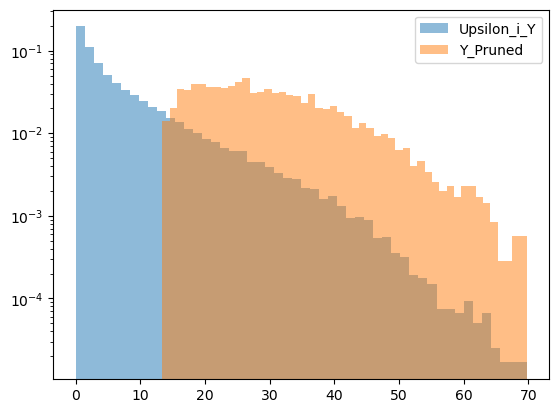

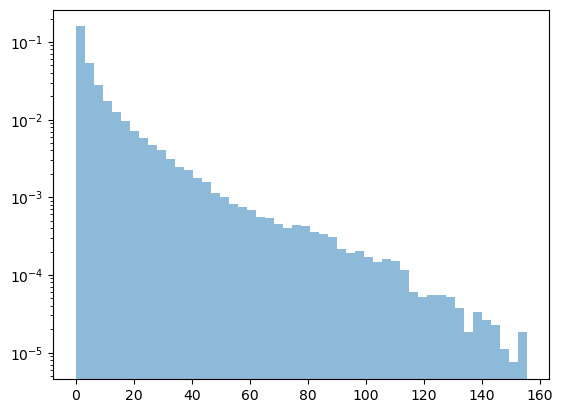

In [ ]:
h = plt.hist(res['Upsilon_i_Y'], bins=50, density=True, alpha=0.5, label='Upsilon_i_Y')
h = plt.hist(res['Upsilon_i_Y'][res['Y_Pruned'][1e-05]], bins=50, density=True, alpha=0.5, label='Y_Pruned')
# h = plt.hist(stats_null_up[p], bins=50, density=True   , label='null', histtype='step', color='black', linewidth=1.5)
plt.yscale('log')
plt.legend()
plt.show()

h = plt.hist(res['Upsilon_i_X'], bins=50, density=True, alpha=0.5, label='Upsilon_i_x')
# h = plt.hist(stats_null_up[1-p], bins=50, density=True, alpha=0.5,  label='null', histtype='step', color='black')
plt.yscale('log')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LogNorm
import matplotlib as mpl
from scipy.ndimage import gaussian_filter

def plot_scatter_matrix_over_under(
    X_over, col_over,
    X_under, col_under,
    feature_names=None,
    sample=None,
    bins_diag=50,
    density_diag=True,
    xlim=None, ylim=None,
    savepath=None,
    bins_offdiag=60,
    cmap_over='Reds',
    cmap_under='Greys',
    upsilon_thresh_over=None,
    upsilon_thresh_under=None,
    smooth_sigma_img=3.0,     # smoothing for imshow
    smooth_sigma_cnt=0.0,     # smoothing for contours (0 = no smoothing)
    n_contours=7,
    lognorm_offdiag=False,
    title=None,
    srb_over=None,
    srb_under=None,
    save_arrays_prefix=None,  # <<< NEW: prefix for saving input arrays
):
    """
    Scatter-matrix style plot with TWO layers:

    - Under-density (background mismodeling) in grayscale
    - Over-density (signal-like) in red, overlaid

    Diagonal: 1D histograms for both (grey filled + red outline).
    Off-diagonal:
        * greyscale under-density heatmap + grey contours
        * red over-density heatmap + black contours

    If save_arrays_prefix is not None, the filtered & subsampled
    X_over/X_under and their cols are saved as .npy files so the
    plot can be recreated from a minimal dataset.
    """

    # --- Prepare data ---
    X_over = np.asarray(X_over)
    col_over = np.asarray(col_over)
    X_under = np.asarray(X_under)
    col_under = np.asarray(col_under)

    # Thresholds
    if upsilon_thresh_over is not None:
        mask_o = col_over >= upsilon_thresh_over
        X_over = X_over[mask_o]
        col_over = col_over[mask_o]

    if upsilon_thresh_under is not None:
        mask_u = col_under >= upsilon_thresh_under
        X_under = X_under[mask_u]
        col_under = col_under[mask_u]

    N_over, D = X_over.shape
    N_under, D2 = X_under.shape
    assert D == D2, "X_over and X_under must have same number of features"

    # Optional subsampling
    if sample is not None:
        if N_over > sample:
            idx = np.random.choice(N_over, sample, replace=False)
            X_over = X_over[idx]
            col_over = col_over[idx]
            N_over = X_over.shape[0]
        if N_under > sample:
            idx = np.random.choice(N_under, sample, replace=False)
            X_under = X_under[idx]
            col_under = col_under[idx]
            N_under = X_under.shape[0]

    if feature_names is None:
        feature_names = [f"x{i}" for i in range(D)]

    # --- NEW: save all relevant arrays for minimal reproduction ---
    if save_arrays_prefix is not None:
        np.save(f"{save_arrays_prefix}_X_over.npy",   X_over)
        np.save(f"{save_arrays_prefix}_col_over.npy", col_over)
        np.save(f"{save_arrays_prefix}_X_under.npy",  X_under)
        np.save(f"{save_arrays_prefix}_col_under.npy", col_under)
        np.save(f"{save_arrays_prefix}_feature_names.npy",
                np.array(feature_names, dtype=object), allow_pickle=True)
        meta = {
            "bins_diag": bins_diag,
            "bins_offdiag": bins_offdiag,
            "density_diag": density_diag,
            "xlim": xlim,
            "ylim": ylim,
            "cmap_over": cmap_over,
            "cmap_under": cmap_under,
            "smooth_sigma_img": smooth_sigma_img,
            "smooth_sigma_cnt": smooth_sigma_cnt,
            "n_contours": n_contours,
            "lognorm_offdiag": lognorm_offdiag,
            "title": title,
            "srb_over": srb_over,
            "srb_under": srb_under,
        }
        np.save(f"{save_arrays_prefix}_meta.npy", meta, allow_pickle=True)

    fig, axes = plt.subplots(D, D, figsize=(2.2 * D, 2.2 * D))

    cmap_o = plt.get_cmap(cmap_over)
    cmap_u = plt.get_cmap(cmap_under)

    im_last = None  # for colorbar

    for i in range(D):
        for j in range(D):
            ax = axes[i, j]

            if i == j:
                # Diagonal: 1D histograms
                if N_under > 0:
                    ax.hist(
                        X_under[:, j],
                        bins=bins_diag,
                        density=density_diag,
                        color="0.8",
                        alpha=0.8,
                        label="under",
                    )
                if N_over > 0:
                    ax.hist(
                        X_over[:, j],
                        bins=bins_diag,
                        density=density_diag,
                        histtype="step",
                        color="darkred",
                        linewidth=1.3,
                        label="over",
                    )

                if i == D - 1:
                    ax.set_xlabel(feature_names[j])
                if j == 0:
                    ax.set_ylabel(feature_names[i])
                else:
                    ax.set_ylabel("")

            else:
                # Off-diagonal: combined under + over densities
                if N_over > 0:
                    x_o = X_over[:, j]
                    y_o = X_over[:, i]
                else:
                    x_o = np.array([])
                    y_o = np.array([])

                if N_under > 0:
                    x_u = X_under[:, j]
                    y_u = X_under[:, i]
                else:
                    x_u = np.array([])
                    y_u = np.array([])

                all_x = np.concatenate([x_o, x_u]) if x_o.size and x_u.size else (x_o if x_o.size else x_u)
                all_y = np.concatenate([y_o, y_u]) if y_o.size and y_u.size else (y_o if y_o.size else y_u)

                if all_x.size == 0 or all_y.size == 0:
                    ax.set_axis_off()
                    continue

                x_min, x_max = all_x.min(), all_x.max()
                y_min, y_max = all_y.min(), all_y.max()

                if xlim is not None:
                    x_min, x_max = xlim
                if ylim is not None:
                    y_min, y_max = ylim

                x_edges = np.linspace(x_min, x_max, bins_offdiag + 1)
                y_edges = np.linspace(y_min, y_max, bins_offdiag + 1)
                x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
                y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])

                # ---- UNDER layer (greys) ----
                if N_under > 0:
                    H_u, _, _ = np.histogram2d(x_u, y_u, bins=[x_edges, y_edges])

                    # copy for image and contours separately
                    H_u_img = gaussian_filter(H_u, sigma=smooth_sigma_img) if smooth_sigma_img > 0 else H_u
                    H_u_cnt = gaussian_filter(H_u, sigma=smooth_sigma_cnt) if smooth_sigma_cnt > 0 else H_u

                    H_u_img_plot = np.where(H_u_img > 0, H_u_img, np.nan)
                    norm_u = Normalize(vmin=np.nanmin(H_u_img_plot), vmax=np.nanmax(H_u_img_plot))

                    ax.imshow(
                        H_u_img_plot.T,
                        origin="lower",
                        aspect="auto",
                        extent=(x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]),
                        cmap=cmap_u,
                        norm=norm_u,
                        alpha=0.8,
                        interpolation="nearest",
                    )

                    valid_u = H_u_cnt > 0
                    if np.any(valid_u):
                        vmin_u = H_u_cnt[valid_u].min()
                        vmax_u = H_u_cnt[valid_u].max()
                        if vmax_u > vmin_u:
                            levels_u = np.linspace(vmin_u, vmax_u, n_contours + 2)[1:-1]
                            ax.contour(
                                x_centers,
                                y_centers,
                                H_u_cnt.T,
                                levels=levels_u,
                                colors="0.4",
                                linewidths=0.7,
                                alpha=0.9,
                            )

                # ---- OVER layer (reds) ----
                if N_over > 0:
                    H_o, _, _ = np.histogram2d(x_o, y_o, bins=[x_edges, y_edges])

                    H_o_img = gaussian_filter(H_o, sigma=smooth_sigma_img) if smooth_sigma_img > 0 else H_o
                    H_o_cnt = gaussian_filter(H_o, sigma=smooth_sigma_cnt) if smooth_sigma_cnt > 0 else H_o

                    if lognorm_offdiag:
                        H_o_img_plot = H_o_img.copy()
                        H_o_img_plot[H_o_img_plot <= 0] = np.nan
                        norm_o = LogNorm(
                            vmin=np.nanmax([np.nanmin(H_o_img_plot), 1e-12]),
                            vmax=np.nanmax(H_o_img_plot),
                        )
                    else:
                        H_o_img_plot = np.where(H_o_img > 0, H_o_img, np.nan)
                        norm_o = Normalize(
                            vmin=np.nanmin(H_o_img_plot),
                            vmax=np.nanmax(H_o_img_plot),
                        )

                    im = ax.imshow(
                        H_o_img_plot.T,
                        origin="lower",
                        aspect="auto",
                        extent=(x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]),
                        cmap=cmap_o,
                        norm=norm_o,
                        alpha=0.55,
                        interpolation="nearest",
                    )
                    im_last = im

                    valid_o = H_o_cnt > 0
                    if np.any(valid_o):
                        vmin_o = H_o_cnt[valid_o].min()
                        vmax_o = H_o_cnt[valid_o].max()
                        if vmax_o > vmin_o:
                            levels_o = np.linspace(vmin_o, vmax_o, n_contours + 2)[1:-1]
                            ax.contour(
                                x_centers,
                                y_centers,
                                H_o_cnt.T,
                                levels=levels_o,
                                colors="r",
                                linewidths=0.7,
                                alpha=0.3,
                            )

                if i < D - 1:
                    ax.set_xticklabels([])
                else:
                    ax.set_xlabel(feature_names[j])

                if j > 0:
                    ax.set_yticklabels([])
                else:
                    ax.set_ylabel(feature_names[i])

                ax.set_xlim(x_min, x_max)
                ax.set_ylim(y_min, y_max)

    # Colorbar for OVER density
    if im_last is not None:
        cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
        cb = mpl.colorbar.ColorbarBase(cax, cmap=cmap_o, norm=im_last.norm)
        cb.set_label("Overdensity density")

    plt.tight_layout(rect=[0, 0, 0.9, 1])

    if title is not None:
        sub = ""
        if srb_over is not None:
            sub += r" Over: $\hat{S}/\sqrt{B} = %.2f$" % srb_over
        if srb_under is not None:
            sub += r"  Under: $\hat{S}/\sqrt{B} = %.2f$" % srb_under
        fig.suptitle(title + sub, fontsize=14, y=1.02)

    if savepath:
        plt.savefig(savepath, dpi=250, bbox_inches="tight")
        plt.close(fig)
    else:
        plt.show()

/tmp/ipykernel_3994828/375563251.py:291: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


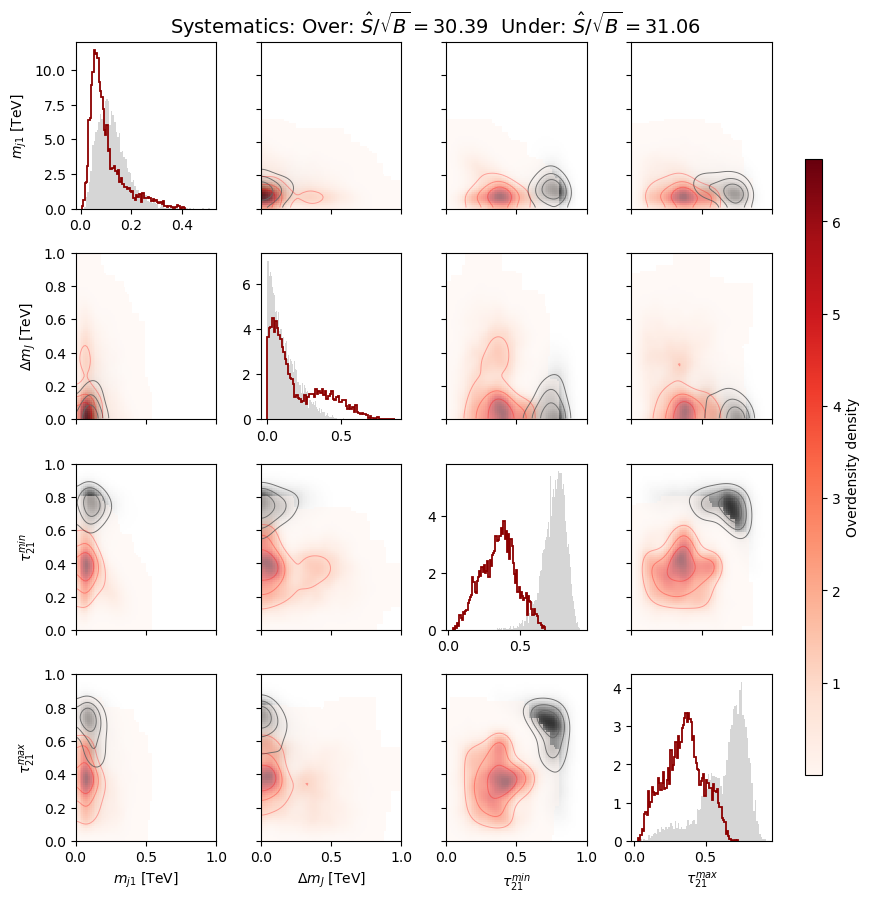

In [ ]:
threshOVER  = repechage_EE_book['Y_OVER_clusters'][0]['Upsilon_alpha_plus']
threshUNDER = repechage_EE_book['X_OVER_clusters'][0]['Upsilon_alpha_minus']


# # Overdensities (Y)
# X_over   = Herwig_SR[:,1:5][res['Upsilon_i_Y'] > threshOVER]
# col_over = res['Upsilon_i_Y'][res['Upsilon_i_Y'] > threshOVER]

# # Underdensities (X)
# X_under   = PYTHIA_SR[:, 1:5][res['Upsilon_i_X'] > threshUNDER]
# col_under = res['Upsilon_i_X'][res['Upsilon_i_X'] > threshUNDER]


# Overdensities (Y)
X_over   = Herwig_SR[:,1:5][repechage_EE_book['Y_OVER_clusters'][0]['Repechaged']]
col_over = res['Upsilon_i_Y'][repechage_EE_book['Y_OVER_clusters'][0]['Repechaged']]

# Underdensities (X)
X_under   = PYTHIA_SR[:, 1:5][repechage_EE_book['X_OVER_clusters'][0]['Repechaged']]
col_under = res['Upsilon_i_X'][repechage_EE_book['X_OVER_clusters'][0]['Repechaged']]


feature_names = [
    r"$m_{j1}$ [TeV]",
    r"$\Delta m_J$ [TeV]",
    r"$\tau_{21}^{min}$",
    r"$\tau_{21}^{max}$",
]

sample_n = min(50000, X_over.shape[0], X_under.shape[0])

srb_over  = EagleEye.S_rootB_estimate_Y_overdensities(res, repechage_EE_book)['s/root(B)']['Total']
srb_under = EagleEye.S_rootB_estimate_X_overdensities(res, repechage_EE_book)['s/root(B)']['Total']

plot_scatter_matrix_over_under(
    X_over, col_over,
    X_under, col_under,
    feature_names=feature_names,
    sample=sample_n,
    bins_diag=80,
    density_diag=True,
    xlim=(0, 1),
    ylim=(0, 1),
    bins_offdiag=80,
    cmap_over='Reds',
    cmap_under='Greys',
    smooth_sigma_img=2.5,
    smooth_sigma_cnt=4,
    n_contours=3,
    lognorm_offdiag=False,
    title="Systematics:",
    srb_over=srb_over,
    srb_under=srb_under,
    save_arrays_prefix="over_under_PYTHIA_HERWIG",  # <<< this triggers .npy dumps
    # savepath="Paper_plots/over_under_combined.png",
)


# (PYTHIA + HERWIG) vs Data (0.6% injection) - Similar to OG LHCO challenge

Full sample shape: (479068, 6)
Signal region shape: (85625, 6)


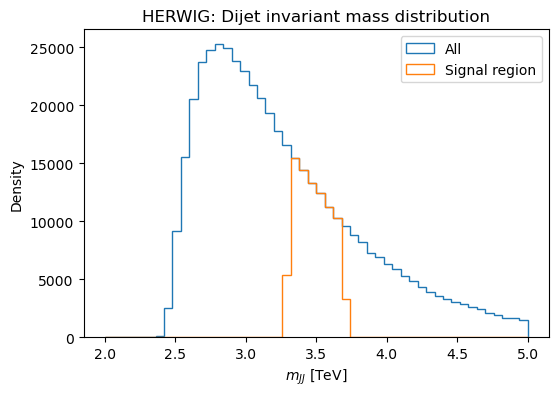

In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

def build_cathode_features_from_h5(h5_path, label=0):
    """
    Build the six-dimensional CATHODE feature array from your HDF5 features.

    Features:
        0: mJJ (TeV)
        1: m_min (TeV)
        2: Δm_J = m_max - m_min (TeV)
        3: tau21_min  (τ21 of lighter jet)
        4: tau21_max  (τ21 of heavier jet)
        5: label (0=background, 1=signal)
    """

    with h5py.File(h5_path, "r") as f:
        mJJ        = np.array(f["/mJJ"])[:, 0]          # shape (N,)
        jet_mass   = np.array(f["/jet_mass"])           # shape (N,2)
        tau21_beta1 = np.array(f["/beta1/ratios"])[:,:,0]  # τ21 = τ2/τ1 for β=1
        tau21_j1 = tau21_beta1[:,0]
        tau21_j2 = tau21_beta1[:,1]

    mJ1, mJ2 = jet_mass[:,0], jet_mass[:,1]

    # --- reorder by jet mass
    is_m1_smaller = mJ1 < mJ2
    m_min = np.where(is_m1_smaller, mJ1, mJ2)
    m_max = np.where(is_m1_smaller, mJ2, mJ1)
    d_mJ  = m_max - m_min

    # reorder tau21 in same order as masses
    tau21_min = np.where(is_m1_smaller, tau21_j1, tau21_j2)
    tau21_max = np.where(is_m1_smaller, tau21_j2, tau21_j1)

    # --- convert GeV → TeV
    out = np.column_stack((
        mJJ/1000.,
        m_min/1000.,
        d_mJ/1000.,
        tau21_min,
        tau21_max,
        np.full_like(mJJ, label)
    ))
    return out


def select_signal_region(features):
    """Apply the CATHODE signal region: 3.3 < mJJ < 3.7 TeV."""
    mask = (features[:,0] > 3.3) & (features[:,0] < 3.7)
    return features[mask]

# Example usage
# fn = "/data/ascaffid/LHC_Olympics/EagleEye/examples/LHC_checks/fastjet/extern/fastjet-contrib/Nsubjettiness/tau_bb2_CATH_features.h5"
fn = "/data/ascaffid/LHC_Olympics/EagleEye/examples/LHC_checks/fastjet/extern/fastjet-contrib/Nsubjettiness/bbox_2_cath_featrues_pre_reorder.h5"
features  = build_cathode_features_from_h5(fn, label=0)
Herwig_SR = select_signal_region(features)



# # Remove all rows with NaNs from Herwig_SR
Herwig_SR = Herwig_SR[~np.isnan(Herwig_SR).any(axis=1)]
features_SR = Herwig_SR  # update features_SR to match cleaned Herwig_SR
features = features[~np.isnan(features).any(axis=1)]
print("Full sample shape:", features.shape)
print("Signal region shape:", features_SR.shape)

# Quick diagnostic plots
plt.figure(figsize=(6,4))
plt.hist(features[:,0], bins=50, range=(2,5), histtype="step", label="All", density=False)
plt.hist(Herwig_SR[:,0], bins=50, range=(2,5), histtype="step", label="Signal region", density=False)
plt.xlabel(r"$m_{JJ}$ [TeV]")
plt.ylabel("Density")
plt.legend()
plt.title("HERWIG: Dijet invariant mass distribution")
plt.show()



Full sample shape: (487131, 6)
Signal region shape: (86366, 6)


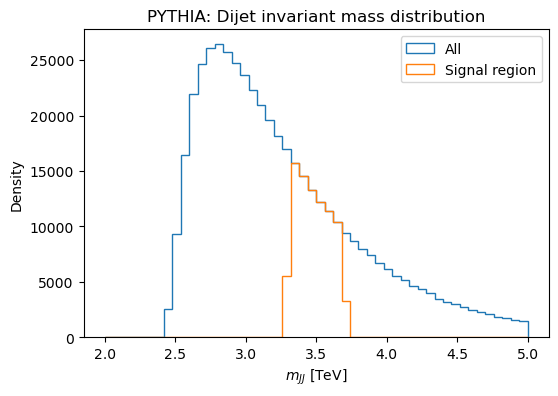

In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt


# Example usage
# fn = "/data/ascaffid/LHC_Olympics/EagleEye/examples/LHC_checks/fastjet/extern/fastjet-contrib/Nsubjettiness/tau_bb2_CATH_features.h5"
fn = "/data/ascaffid/LHC_Olympics/EagleEye/examples/LHC_checks/fastjet/extern/fastjet-contrib/Nsubjettiness/PYTHIA_cath_featrues_pre_reorder.h5"
features  = build_cathode_features_from_h5(fn, label=0)
PYTHIA_SR = select_signal_region(features)



# # Remove all rows with NaNs from Herwig_SR
PYTHIA_SR = PYTHIA_SR[~np.isnan(PYTHIA_SR).any(axis=1)]
features_SR = PYTHIA_SR  # update features_SR to match cleaned Herwig_SR
features = features[~np.isnan(features).any(axis=1)]
print("Full sample shape:", features.shape)
print("Signal region shape:", features_SR.shape)

# Quick diagnostic plots
plt.figure(figsize=(6,4))
plt.hist(features[:,0], bins=50, range=(2,5), histtype="step", label="All", density=False)
plt.hist(PYTHIA_SR[:,0], bins=50, range=(2,5), histtype="step", label="Signal region", density=False)
plt.xlabel(r"$m_{JJ}$ [TeV]")
plt.ylabel("Density")
plt.legend()
plt.title("PYTHIA: Dijet invariant mass distribution")
plt.show()



In [ ]:
import pandas as pd
import os
# ------------------------------------------------------------
#  CATHODE-style feature builder and plotter
# ------------------------------------------------------------
def build_cathode_features(samples):
    """
    Convert a [N,15] array with (pxj1,...,mj2,label) into the
    six-dimensional feature vector used by the CATHODE paper:

        0: m_JJ          (TeV)
        1: m_min         (TeV)   --  the smaller of mj1, mj2
        2: Δm_J = m_max-m_min (TeV)
        3: tau21_min            --  τ21 of the jet with m_min
        4: tau21_max            --  τ21 of the jet with m_max
        5: label  (0 = background, 1 = signal)
    """

    # -------- invariant mass m_JJ (same expression you already use)
    px1, py1, pz1 = samples[:, 0], samples[:, 1], samples[:, 2]
    px2, py2, pz2 = samples[:, 3], samples[:, 4], samples[:, 5]
    m1 , m2       = samples[:,12], samples[:,13]

    E1 = np.sqrt(px1**2 + py1**2 + pz1**2 + m1**2)
    E2 = np.sqrt(px2**2 + py2**2 + pz2**2 + m2**2)
    p1_dot_p2 = px1*px2 + py1*py2 + pz1*pz2
    mJJ = np.sqrt(np.maximum(m1**2 + m2**2 + 2*(E1*E2 - p1_dot_p2), 0.0))

    # -------- jet-mass ordering
    is_m1_smaller = m1 < m2
    m_min  = np.where(is_m1_smaller, m1, m2)
    m_max  = np.where(is_m1_smaller, m2, m1)
    d_mJ   = m_max - m_min                # always ≥ 0

    # -------- keep τ21 in the same order as the masses
    tau21_j1, tau21_j2 = samples[:, 8], samples[:, 9]
    tau21_min = np.where(is_m1_smaller, tau21_j1, tau21_j2)
    tau21_max = np.where(is_m1_smaller, tau21_j2, tau21_j1)

    labels = samples[:,14]

    # -------- convert GeV → TeV for mass-like quantities
    out = np.column_stack((mJJ/1000.,
                           m_min/1000.,
                           d_mJ/1000.,
                           tau21_min,
                           tau21_max,
                           labels))
    return out

# Plotting
def plot_feature_distributions(inner_mix_samples, inner_ref_samples, feature_names):
    """
    Plots the distributions of the 4 features in inner_mix_samples and inner_ref_samples.

    Parameters:
    - inner_mix_samples: numpy.ndarray, mixed samples data.
    - inner_ref_samples: numpy.ndarray, reference samples data.
    - feature_names: list of str, names of the features to be plotted.
    """
    num_features = inner_mix_samples.shape[1]
    fig, axes = plt.subplots(1, num_features, figsize=(20, 5), sharey=False)

    for i, ax in enumerate(axes):
        ax.hist(inner_ref_samples[:, i], bins=70, alpha=0.5, label='Reference', density=True, color='blue')
        ax.hist(inner_mix_samples[:, i], bins=70, alpha=0.5, label='Mixed', density=True, color='orange')
        ax.set_title(feature_names[i])
        ax.set_xlabel('Value')
        ax.set_ylabel('Density')
        ax.legend()

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Load dataset
file_path = '/data/ascaffid/LHC_Olympics/EagleEye_LHC/data/events_anomalydetection_v2.features.h5'
df_features = pd.read_hdf(file_path)
# Compute the three-momentum components' magnitudes
df_features['|p|1']      = np.sqrt(df_features['pxj1']**2 + df_features['pyj1']**2 + df_features['pzj1']**2)
df_features['|p|2']      = np.sqrt(df_features['pxj2']**2 + df_features['pyj2']**2 + df_features['pzj2']**2)
# Compute substructure features
df_features['tau21j1']   = df_features['tau2j1'] / df_features['tau1j1']
df_features['tau21j2']   = df_features['tau2j2'] / df_features['tau1j2']
df_features['tau32j1']   = df_features['tau3j1'] / df_features['tau2j1']
df_features['tau32j2']   = df_features['tau3j2'] / df_features['tau2j2']
# Select new features including three-momenta components and labels
selected_columns         = ['pxj1', 'pyj1', 'pzj1', 'pxj2', 'pyj2', 'pzj2', '|p|1', '|p|2', 
                    'tau21j1', 'tau21j2', 'tau32j1', 'tau32j2', 'mj1', 'mj2', 'label']
df_features              = df_features[selected_columns]
LHC_data1p1M             = df_features.to_numpy()
LHC_data1p1M[np.isnan(LHC_data1p1M)] = 0
LHC0_data                = build_cathode_features(LHC_data1p1M)
LHC0_background          = LHC0_data[LHC0_data[:,-1] == 0]
LHC0_signal              = LHC0_data[LHC0_data[:,-1] == 1]


# Select only the inner-window events (3.3–3.7 TeV):
LHC0_signal_mask         = (LHC0_signal[:,0] >= 3.3) & (LHC0_signal[:,0] <= 3.7)
LHC0_signal              = LHC0_signal[LHC0_signal_mask]
LHC0_background_mask     = (LHC0_background[:,0] >= 3.3) & (LHC0_background[:,0] <= 3.7)
LHC0_background          = LHC0_background[LHC0_background_mask]
path_extra_data          = '/data/ascaffid/LHC_Olympics/CATHODE/separated_data'
innerdata_extrasig_train = np.load(os.path.join(path_extra_data, 'innerdata_extrasig_train.npy'))
innerdata_extrasig_val   = np.load(os.path.join(path_extra_data, 'innerdata_extrasig_val.npy'))
innerdata_extrabkg_train = np.load(os.path.join(path_extra_data, 'innerdata_extrabkg_train.npy'))
innerdata_extrabkg_val   = np.load(os.path.join(path_extra_data, 'innerdata_extrabkg_val.npy'))
innerdata_extrabkg_test  = np.load(os.path.join(path_extra_data, 'innerdata_extrabkg_test.npy'))
total_extra_bkg          = np.concatenate((innerdata_extrabkg_train, innerdata_extrabkg_val, innerdata_extrabkg_test), axis=0)
total_extra_sig          = np.concatenate((innerdata_extrasig_train, innerdata_extrasig_val), axis=0)
TOTAL_bkg                = np.concatenate((LHC0_background, total_extra_bkg), axis=0)
TOTAL_sig                = np.concatenate((LHC0_signal, total_extra_sig), axis=0)


# Generate reference and mixed samples with same number of events but keeping the signal injection at 0.3% and increwasing nnumber of events in both sets
number_reference_samples    = 121352 # len(LHC0_background)
injection_fraction          = 0.0064


number_signal_samples       = int(injection_fraction * number_reference_samples)

# Eventaully will need random permutation
reference_samples           = total_extra_bkg[:number_reference_samples, :]   # CATHODE interpolated samples
mixed_samples               = np.concatenate([LHC0_background, TOTAL_sig[:number_signal_samples,:] ], axis=0 )

print("number_signal_samples, mixed_samples.shape, reference_samples.shape: ", number_signal_samples, mixed_samples.shape,reference_samples.shape)
print("Initial S/root(B) = ", number_signal_samples/np.sqrt(number_reference_samples))



number_signal_samples, mixed_samples.shape, reference_samples.shape:  776 (122128, 6) (121352, 6)
Initial S/root(B) =  2.227605349173685


In [ ]:
bkg1 = PYTHIA_SR[:,1:5][:number_reference_samples]    # LHCO background samples
bkg2 = Herwig_SR[:,1:5][:number_reference_samples]    # Herwig background samples
data = mixed_samples[:,1:-1]                          # LHCO mixed samples

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2
import time
import sys
sys.path.append('../../eagleeye')
import EagleEye as EagleEye
import utils_EE 
import importlib
importlib.reload(EagleEye)

from utils_EE import compute_the_null
# --- user-configurable ---
# Use KM if present, otherwise fallback

KM    = 500
p_ext = 1e-5
# Upsilon_star_plus = 14
n_jobs = 50
do_IDE = True   # faster for exploratory runs
B_emp = 50000    # number of empirical combined-null samples (adjust for precision/speed)
save_prefix = "combination_analysis_PYTHIA_HERWIG_0_6_injection"

# --- dataset variables that must exist ---
# bkg1, bkg2, data  (user supplied in your message)
refs = [bkg1, bkg2]
R = len(refs)
Y = data
Ny = Y.shape[0]

# containers
per_ref_ups = []
per_ref_stats_null = []
res_dicts = []

Z_partition = 2.65
repechage_info_per_ref = []
# run Soar for each reference
print("Running Soar separately for each reference (do_IDE=%s)..." % do_IDE)
start = time.time()
for r_idx, Xr in enumerate(refs):
    p_r = len(Y) / (len(Y) + len(Xr))
    print(f"\nReference {r_idx+1}/{R}: n_ref={len(Xr)}, p_r={p_r:.6f}")
    
    # compute the null for this p_r and KM (fast if you already have it cached)
    stats_null_r = compute_the_null(p=p_r, K_M=KM,N=50000)
    # stats_null_r = {p_r:[Upsilon_star_plus],1-p_r:[Upsilon_star_plus]}

    print("Threshold for p_ext=%.1e: %.3f" % (p_ext, np.quantile(stats_null_r[p_r], 1.0 - p_ext)))
    # run Soar (quick mode)
    res_r, _ = EagleEye.Soar(Xr, Y, K_M=KM, p_ext=p_ext, n_jobs=n_jobs,
                             stats_null=stats_null_r, result_dict_in={}, do_IDE=do_IDE)
    

    ups_r = res_r['Upsilon_i_Y']   # length Ny
    per_ref_ups.append(ups_r)
    res_dicts.append(res_r)
    # pick the appropriate null Upsilon array for the "plus" side (value keyed by p_r)
    # compute_the_null returns stats_null[p] (an array of sampled null upsilons) 
    # use stats_null_r[p_r] if exact match; otherwise try nearest key
    if p_r in stats_null_r:
        null_arr = stats_null_r[p_r]
    else:
        # choose closest key numerically (defensive)
        keys = np.array(list(stats_null_r.keys()), dtype=float)
        idx_closest = np.argmin(np.abs(keys - p_r))
        null_arr = stats_null_r[keys[idx_closest]]
    per_ref_stats_null.append(np.asarray(null_arr))


    print(f"\n=== Per-bkg repechage for ref {r_idx+1} ===")


    Xr_arr = np.asarray(Xr, dtype=float)
    Y_arr  = np.asarray(Y, dtype=float)


    # Partitioning
    clusters_plus, clusters_minus = utils_EE.partitioning_function(
        Xr_arr, Y_arr, res_r, p_ext=p_ext, Z=Z_partition
    )

    # Repechage
    rep_book = EagleEye.Repechage(
        Xr_arr, Y_arr, res_r,
        (clusters_plus, clusters_minus),
        p_ext=p_ext,
        quant=0,
    )

    # S/√B estimates per Y_OVER cluster
    est_dict = EagleEye.S_rootB_estimate_Y_overdensities(res_r, rep_book)
    srb_map  = est_dict.get('s/root(B)', {})

    print(f"  Found {len(rep_book.get('Y_OVER_clusters', {}))} Y_OVER repechage clusters. In bkg ref {r_idx+1}.")
    print(f"  S/√B estimates for clusters: {srb_map}")
    # Collect per-cluster info for this ref
    Y_over = rep_book.get('Y_OVER_clusters', {})
    clusters_info = []   # list of { 'key', 'idx', 'n', 's_est' }

    if isinstance(Y_over, dict):
        for key, info in Y_over.items():
            rep_list = info.get('Repechaged', [])
            if rep_list is None:
                rep_list = []
            try:
                idx_arr = np.asarray(rep_list, dtype=int)
            except Exception:
                idx_arr = np.array([], dtype=int)

            n_rep = idx_arr.size
            # try both string/int keys in srb_map
            s_est = srb_map.get(key, srb_map.get(int(key), None))

            clusters_info.append({
                'key'   : key,
                'idx'   : idx_arr,
                'n'     : n_rep,
                's_est' : s_est,
            })

    repechage_info_per_ref.append({
        'rep_book'      : rep_book,
        'srb_map'       : srb_map,
        'clusters_info' : clusters_info,
    })
# --------------------------------------------------------
print("Done. elapsed: %.1f s" % (time.time() - start))


# ---------------------------------------------------------------------
# Stack results: shape (R, Ny)
per_ref_ups = np.vstack(per_ref_ups)   # R x Ny
# combined stats
fisher_obs = 2.0 * np.sum(per_ref_ups, axis=0)    # length Ny
sum_ups = np.sum(per_ref_ups, axis=0)             # proportional to fisher_obs

# --- Build empirical null for Fisher by sampling from per-ref null arrays ---
# Defensive: ensure all per_ref_stats_null have length >= 1
min_len = min(arr.size for arr in per_ref_stats_null)
if min_len == 0:
    raise RuntimeError("One of the per-reference null arrays is empty — compute_the_null returned nothing.")

# choose B_emp not larger than min_len unless we sample with replacement
B = min(B_emp, min_len)
rng = np.random.default_rng(123456)

# sample indices for each ref (with replacement if B > min_len)
idxs = rng.integers(0, per_ref_stats_null[0].size, size=(B, R))
# produce matrix of shape (B, R) of Upsilon null draws
U_null_matrix = np.column_stack([
    per_ref_stats_null[r][idxs[:, r] % per_ref_stats_null[r].size]
    for r in range(R)
])
fisher_null = 2.0 * np.sum(U_null_matrix, axis=1)   # length B

# --- Empirical p-values for each observed fisher statistic ---
# p_empirical_i = proportion of fisher_null >= fisher_obs[i]
# We'll vectorize using broadcasting (may be memory heavy if Ny large; otherwise do loop)
# Use efficient sorting approach: sort fisher_null and use searchsorted
fisher_null_sorted = np.sort(fisher_null)
# survival probability: fraction >= x
def emp_p_from_null_sorted(x_array, null_sorted):
    # returns array of same shape as x_array
    B = null_sorted.size
    # index of first element > x: use searchsorted(right)
    idx = np.searchsorted(null_sorted, x_array, side='right')
    # count >= x = B - idx
    return (B - idx) / float(B)

p_empirical = emp_p_from_null_sorted(fisher_obs, fisher_null_sorted)

# --- Theoretical chi2 p-values (df = 2R) ---
df = 2 * R
p_chi2 = chi2.sf(fisher_obs, df=df)

# --- thresholds for significance ---
th_chi2 = chi2.isf(p_ext, df=df)           # theoretical threshold
th_empirical = np.quantile(fisher_null, 1.0 - p_ext)  # empirical threshold

# counts flagged
n_flag_chi2 = np.sum(fisher_obs > th_chi2)
n_flag_emp = np.sum(p_empirical < p_ext)
n_flag_emp_thresh = np.sum(fisher_obs > th_empirical)


print(f"Sum of per-ref thresholds: {summed_thresh:.3f}")



Running Soar separately for each reference (do_IDE=True)...

Reference 1/2: n_ref=86366, p_r=0.585763
Threshold for p_ext=1.0e-05: 13.933
-----------------------------------------------------------------
Eagle...Soar!
-----------------------------------------------------------------
Compute the nearest neighbours
KNN completed: 0.00 %
KNN completed: 4.80 %
KNN completed: 9.59 %
KNN completed: 14.39 %
KNN completed: 19.19 %
KNN completed: 23.98 %
KNN completed: 28.78 %
KNN completed: 33.57 %
KNN completed: 38.37 %
KNN completed: 43.17 %
KNN completed: 47.96 %
KNN completed: 52.76 %
KNN completed: 57.56 %
KNN completed: 62.35 %
KNN completed: 67.15 %
KNN completed: 71.94 %
KNN completed: 76.74 %
KNN completed: 81.54 %
KNN completed: 86.33 %
KNN completed: 91.13 %
KNN completed: 95.93 %
-----------------------------------------------------------------
Flagging of putative anomalous points
-----------------------------------------------------------------


<IPython.core.display.Math object>

'DONE!'

<IPython.core.display.Math object>

'DONE!'

...

'DONE!'

<IPython.core.display.Math object>

alpha = 1
alpha = 2
alpha = 3
alpha = 4
alpha = 5
alpha = 6
alpha = 7
alpha = 8
alpha = 9
alpha = 10
alpha = 11
alpha = 12
alpha = 13
alpha = 14


'DONE!'

  Found 3 Y_OVER repechage clusters. In bkg ref 2.
  S/√B estimates for clusters: {'Total': 266.50827510841367, 0: 266.68541750179924, 1: 4.320911228633175, 2: 4.00731370953346}
Done. elapsed: 1919.0 s

Combination summary:
 R = 2, df_chi2 = 4
 chi2 theoretical threshold (p_ext=1e-05): 28.473
 empirical Fisher threshold (p_ext=1e-05): 40.943
 flagged by chi2 threshold: 16496 / 122128
 flagged by empirical p (p_emp < 1e-05): 12299 / 122128
 flagged by empirical stat-threshold: 12625 / 122128
 sum of per-ref thresholds: 26.943


In [ ]:
# ============================================================
# SAVE ALL RELEVANT OBJECTS FROM THE COMBINATION RUN
# ============================================================

save_file = f"herwig_plus_pythia_vs_data_0_6_inj.npz"

np.savez(
    save_file,

    # --- core configuration ---
    KM=KM,
    p_ext=p_ext,
    n_jobs=n_jobs,
    do_IDE=do_IDE,
    B_emp=B_emp,
    Z_partition=Z_partition,

    # --- input references & data ---
    # note: arrays can be large, so store as object only if needed
    # Uncomment below if you also want the raw refs/data stored.
    # refs=np.array(refs, dtype=object),
    # Y=Y,

    # --- Per-reference results from Soar ---
    per_ref_ups=per_ref_ups,                           # (R, Ny)
    per_ref_stats_null=np.array(per_ref_stats_null, dtype=object),
    res_dicts=np.array(res_dicts, dtype=object),       # list of full res dicts

    # --- Repechage info per reference ---
    repechage_info_per_ref=np.array(repechage_info_per_ref, dtype=object),  # list of dicts with rep_book, srb_map, clusters_info

    # --- Combined Fisher statistics ---
    fisher_obs=fisher_obs,              # length Ny
    sum_ups=sum_ups,                    # length Ny
    fisher_null=fisher_null,            # length B
    fisher_null_sorted=fisher_null_sorted,
    p_empirical=p_empirical,
    p_chi2=p_chi2,

    # --- thresholds ---
    th_chi2=th_chi2,
    th_empirical=th_empirical,
    summed_thresh=summed_thresh,

    # --- flag counts ---
    n_flag_chi2=n_flag_chi2,
    n_flag_emp=n_flag_emp,
    n_flag_emp_thresh=n_flag_emp_thresh,

    # --- meta ---
    R=R,
    Ny=Ny,
    save_prefix=save_prefix,
)

print(f"\nSaved combination run objects to:\n  {save_file}")
print(f"  - Includes repechage_info_per_ref with {len(repechage_info_per_ref)} reference(s)")
print(f"  - Z_partition = {Z_partition}")


Saved combination run objects to:
  herwig_plus_pythia_vs_data_0_6_inj.npz
  - Includes repechage_info_per_ref with 2 reference(s)
  - Z_partition = 2.65


In [ ]:
import numpy as np
import os

fname = "herwig_plus_pythia_vs_data_0_6_inj.npz"

# adjust path if the file lives elsewhere
if not os.path.exists(fname):
    alt = os.path.join("/mnt/data", fname)
    if os.path.exists(alt):
        fname = alt
    else:
        raise FileNotFoundError(f"Could not find {fname} (checked cwd and /mnt/data).")

# Load the npz file
npz = np.load(fname, allow_pickle=True)

# Extract each variable into the namespace
KM = npz['KM'].item() if npz['KM'].shape == () else npz['KM']
p_ext = npz['p_ext'].item() if npz['p_ext'].shape == () else npz['p_ext']
n_jobs = npz['n_jobs'].item() if npz['n_jobs'].shape == () else npz['n_jobs']
do_IDE = npz['do_IDE'].item() if npz['do_IDE'].shape == () else npz['do_IDE']
B_emp = npz['B_emp'].item() if npz['B_emp'].shape == () else npz['B_emp']

# Per-reference results
per_ref_ups = npz['per_ref_ups']
per_ref_stats_null = npz['per_ref_stats_null']
res_dicts = npz['res_dicts']

# Combined Fisher statistics
fisher_obs = npz['fisher_obs']
sum_ups = npz['sum_ups']
fisher_null = npz['fisher_null']
fisher_null_sorted = npz['fisher_null_sorted']
p_empirical = npz['p_empirical']
p_chi2 = npz['p_chi2']

# Thresholds
th_chi2 = npz['th_chi2'].item() if npz['th_chi2'].shape == () else npz['th_chi2']
th_empirical = npz['th_empirical'].item() if npz['th_empirical'].shape == () else npz['th_empirical']
summed_thresh = npz['summed_thresh'].item() if npz['summed_thresh'].shape == () else npz['summed_thresh']

# Flag counts
n_flag_chi2 = npz['n_flag_chi2'].item() if npz['n_flag_chi2'].shape == () else npz['n_flag_chi2']
n_flag_emp = npz['n_flag_emp'].item() if npz['n_flag_emp'].shape == () else npz['n_flag_emp']
n_flag_emp_thresh = npz['n_flag_emp_thresh'].item() if npz['n_flag_emp_thresh'].shape == () else npz['n_flag_emp_thresh']

# Meta
R = npz['R'].item() if npz['R'].shape == () else npz['R']
Ny = npz['Ny'].item() if npz['Ny'].shape == () else npz['Ny']

print("Successfully loaded all variables from", fname)
print("\nScalar values:")
print(f"  KM = {KM}")
print(f"  p_ext = {p_ext}")
print(f"  n_jobs = {n_jobs}")
print(f"  do_IDE = {do_IDE}")
print(f"  B_emp = {B_emp}")
print(f"  R = {R}")
print(f"  Ny = {Ny}")
print(f"\nThresholds:")
print(f"  th_chi2 = {th_chi2}")
print(f"  th_empirical = {th_empirical}")
print(f"  summed_thresh = {summed_thresh}")
print(f"\nArray shapes:")
print(f"  per_ref_ups: {per_ref_ups.shape}")
print(f"  fisher_obs: {fisher_obs.shape}")
print(f"  fisher_null: {fisher_null.shape}")

Successfully loaded all variables from herwig_plus_pythia_vs_data_0_6_inj.npz

Scalar values:
  KM = 500
  p_ext = 1e-05
  n_jobs = 50
  do_IDE = True
  B_emp = 50000
  R = 2
  Ny = 122128

Thresholds:
  th_chi2 = 28.473255424006034
  th_empirical = 37.13363275791885
  summed_thresh = 25.479304616371195

Array shapes:
  per_ref_ups: (2, 122128)
  fisher_obs: (122128,)
  fisher_null: (50000,)


In [ ]:
# Defensive wrapper for partitioning on Fisher-derived res
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2
import time
import sys
sys.path.append('../../eagleeye')
import EagleEye as EagleEye
import utils_EE 
import importlib
importlib.reload(EagleEye)
import importlib
# importlib.reload(multi_bkg_check_utils)
from multi_bkg_check_utils import plot_scatter_matrix_with_colored_diag

# --- Resolve inputs (fall back to alternatives if needed) ---
if 'reference_samples' in globals():
    X_ref_full = reference_samples
elif 'bkg1' in globals() and 'bkg2' in globals():
    X_ref_full = np.vstack([bkg1, bkg2])
elif 'bkg1' in globals():
    X_ref_full = bkg1
else:
    raise RuntimeError("No reference array found: provide reference_samples or bkg1/bkg2.")

try:
    X_features_full = features_all  # your earlier alias
except NameError:
    try:
        X_features_full = data
    except NameError:
        raise RuntimeError("No feature matrix found: set features_all or data.")

try:
    fisher = fisher_obs
except NameError:
    raise RuntimeError("fisher_obs not found in namespace.")

try:
    thresh = th_empirical
except NameError:
    raise RuntimeError("th_empirical not found in namespace.")

print("Reference shape:", X_ref_full.shape, "Feature (Y) shape:", X_features_full.shape)

# SET THRESHOLD AS SUMMED NULL THRESHOLD

thresh=summed_thresh

# --- Align dimensions (minimal, non-destructive fallback) ---
min_cols = min(X_ref_full.shape[1], X_features_full.shape[1])
if X_ref_full.shape[1] != X_features_full.shape[1]:
    print(f"Warning: mismatched feature dims. Truncating both to first {min_cols} columns.")
X_ref = np.asarray(X_ref_full)[:, :min_cols].astype(float)
X_features = np.asarray(X_features_full)[:, :min_cols].astype(float)

nX = X_ref.shape[0]
nY = X_features.shape[0]
print("Using aligned shapes -> X_ref:", X_ref.shape, "Y:", X_features.shape)

# --- Build minimal res dict expected by partitioning_function ---
# res_comb should mimic the Soar output structure sufficiently for partitioner
res_comb = {
    'Upsilon_i_Y': np.asarray(fisher).astype(float),              # length nY
    'Upsilon_star_plus': {p_ext: float(thresh)},  
    'Upsilon_star_minus': {p_ext: float(thresh)},
                                    # threshold mapping
    # injection placeholders (lengths must match nX / nY as used by utils_EE)
    # set zeros for injected arrays (no injected 'upsilon' info available)
    'Upsilon_i_Y_inj': np.zeros(nX, dtype=float),                # length nX (injected)
    'Upsilon_i_X': np.zeros(nX, dtype=float),
    'Upsilon_i_X_inj': np.zeros(nY, dtype=float),
    # keep other fields optional / empty
    'Knn_model': None,
    'stats_null': {},
    'K_M': 1000,
    'p_ext': p_ext
}

# --- Call partitioner (DPA) with aligned arrays ---
Z_for_partition = 10.63
clusters_plus, clusters_minus = utils_EE.partitioning_function(X_ref, X_features, res_comb, p_ext=p_ext, Z=Z_for_partition)

# --- Extract Y-only indices per cluster (as indices into X_features / fisher) ---
y_clusters = []
for i, cluster in enumerate(clusters_plus):
    arr = np.asarray(cluster, dtype=int)
    # Y indices in combined cluster are >= nX
    y_idx = arr[arr >= nX] - nX
    y_clusters.append(y_idx)

print("Clusters (Y-side) sizes:")
for i, c in enumerate(y_clusters):
    print(f" cluster {i}: {c.size} points")

print("Empirical threshold used for partitioning:", summed_thresh)

# --- Plot largest clusters (2D scatter of first two aligned features) ---
min_size_to_plot = 1
large_ids = [i for i,c in enumerate(y_clusters) if c.size >= min_size_to_plot]


# for cid in large_ids:
    # idx = y_clusters[cid]
    # plt.figure(figsize=(6,5))
    # plt.scatter(X_features[:,0], X_features[:,1], c='silver', s=6, alpha=0.25)
    # sc = plt.scatter(X_features[idx,0], X_features[idx,1], c=fisher[idx], cmap='viridis', s=20)
    # plt.colorbar(sc, label='Fisher stat')
    # plt.title(f"Cluster {cid} (Y-side) n={idx.size}")
    # plt.xlabel("feat 0"); plt.ylabel("feat 1")
    # plt.tight_layout()
    # outname = f"{save_prefix}_fisher_cluster_{cid}_2d.png"
    # plt.savefig(outname, dpi=150)
    # print("Saved", outname)
    # plt.show()

# Loop over all large clusters
srootb_results = {}  # Dictionary to store results
for cid in large_ids:
    idx = y_clusters[cid]
    
    # Get true labels for this cluster
    labels_cluster = mixed_samples[:,-1][idx]
    
    # Count signal and background
    S_true = np.sum(labels_cluster == 1)
    B_true = np.sum(labels_cluster == 0)
    
    # Compute S/sqrt(B)
    if B_true > 0:
        srootb_cluster = S_true / np.sqrt(B_true)
        srootb_results[cid] = {'S': S_true, 'B': B_true, 'S_sqrt_B': srootb_cluster}
        print(f"Cluster {cid}: S={S_true}, B={B_true}, S/√B={srootb_cluster:.3f}")
    else:
        srootb_results[cid] = {'S': S_true, 'B': B_true, 'S_sqrt_B': None}
        print(f"Cluster {cid}: S={S_true}, B=0, S/√B undefined")

print("\nSaved S/√B results:", srootb_results)
    
    # if idx.size > 0:
    #     X_sel = X_features[idx]
    #     col = fisher[idx]
    #     if X_sel.shape[1] == 4:
    #         feature_names = [
    #             r"$m_{j1}$ [TeV]",
    #             r"$\Delta m_J$ [TeV]",
    #             r"$\tau_{21}^{min}$",
    #             r"$\tau_{21}^{max}$",
    #         ]
    #     else:
    #         feature_names = [f"f{i}" for i in range(X_sel.shape[1])]
    #     plot_scatter_matrix_with_colored_diag(
    #         X_sel, col, feature_names=feature_names,
    #         sample=min(50000, X_sel.shape[0]),
    #         bins_diag=100, density_diag=True, diag_agg='max',
    #         xlim=(0,1), ylim=(0,1),
    #         # savepath=f"{save_prefix}_cluster_{cid}_scatter_matrix_colored_diag_max.png"
    #     )


Reference shape: (121352, 6) Feature (Y) shape: (122128, 4)
Using aligned shapes -> X_ref: (121352, 4) Y: (122128, 4)
-----------------------------------------------------------------
Clustering
-----------------------------------------------------------------
Clusters (Y-side) sizes:
 cluster 0: 16883 points
 cluster 1: 325 points
Empirical threshold used for partitioning: 26.9426566418908
Cluster 0: S=2, B=16881, S/√B=0.015
Cluster 1: S=182, B=143, S/√B=15.220

Saved S/√B results: {0: {'S': 2, 'B': 16881, 'S_sqrt_B': 0.015393270840115785}, 1: {'S': 182, 'B': 143, 'S_sqrt_B': 15.219604582129051}}


In [ ]:
X_over   = np.load("over_under_PYTHIA_HERWIG_X_over.npy")
col_over = np.load("over_under_PYTHIA_HERWIG_col_over.npy")
X_under  = np.load("over_under_PYTHIA_HERWIG_X_under.npy")
col_under = np.load("over_under_PYTHIA_HERWIG_col_under.npy")
feature_names = np.load("over_under_PYTHIA_HERWIG_feature_names.npy", allow_pickle=True).tolist()
meta = np.load("over_under_PYTHIA_HERWIG_meta.npy", allow_pickle=True).item()

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LogNorm
import matplotlib as mpl
from scipy.ndimage import gaussian_filter
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LogNorm
import matplotlib as mpl
from scipy.ndimage import gaussian_filter

def plot_scatter_matrix_over_under(
    X_over, col_over,
    X_under, col_under,
    feature_names=None,
    sample=None,
    bins_diag=50,
    density_diag=True,
    xlim=None, ylim=None,
    savepath=None,
    bins_offdiag=60,
    cmap_over='Reds',
    cmap_under='Greys',
    upsilon_thresh_over=None,
    upsilon_thresh_under=None,
    smooth_sigma_img=3.0,
    smooth_sigma_cnt=0.0,
    n_contours=7,
    lognorm_offdiag=False,
    title=None,
    srb_over=None,
    srb_under=None,
    srb_true=None,
    save_arrays_prefix=None,
    X_overlay=None,              # Fisher cluster points
    overlay_smooth_sigma=3.0,    # smoothing for overlay
    overlay_cmap='YlOrBr',       # yellowish colormap
):
    """
    Scatter-matrix with:
      - Under-density (X_under) in grayscale
      - Over-density (X_over) in red
      - OPTIONAL: overlay density/contours from X_overlay in yellow.
    """

    # --- Prepare data ---
    X_over = np.asarray(X_over)
    col_over = np.asarray(col_over)
    X_under = np.asarray(X_under)
    col_under = np.asarray(col_under)

    if X_overlay is not None:
        X_overlay = np.asarray(X_overlay)

    # Thresholds
    if upsilon_thresh_over is not None:
        mask_o = col_over >= upsilon_thresh_over
        X_over = X_over[mask_o]
        col_over = col_over[mask_o]

    if upsilon_thresh_under is not None:
        mask_u = col_under >= upsilon_thresh_under
        X_under = X_under[mask_u]
        col_under = col_under[mask_u]

    N_over, D = X_over.shape
    N_under, D2 = X_under.shape
    assert D == D2, "X_over and X_under must have same number of features"
    if X_overlay is not None:
        assert X_overlay.shape[1] == D, "X_overlay must have same feature dims as X_over/X_under"

    # Optional subsampling
    if sample is not None:
        if N_over > sample:
            idx = np.random.choice(N_over, sample, replace=False)
            X_over = X_over[idx]
            col_over = col_over[idx]
            N_over = X_over.shape[0]
        if N_under > sample:
            idx = np.random.choice(N_under, sample, replace=False)
            X_under = X_under[idx]
            col_under = col_under[idx]
            N_under = X_under.shape[0]

    if feature_names is None:
        feature_names = [f"x{i}" for i in range(D)]

    fig, axes = plt.subplots(D, D, figsize=(2.2 * D, 2.2 * D))

    cmap_o = plt.get_cmap(cmap_over)
    cmap_u = plt.get_cmap(cmap_under)
    cmap_ov = plt.get_cmap(overlay_cmap)    # yellow overlay

    im_last = None  # for colorbar (over layer)

    for i in range(D):
        for j in range(D):
            ax = axes[i, j]

            if i == j:
                # Diagonal hists
                if N_under > 0:
                    ax.hist(
                        X_under[:, j],
                        bins=bins_diag,
                        density=density_diag,
                        color="0.8",
                        alpha=0.8,
                    )
                if N_over > 0:
                    ax.hist(
                        X_over[:, j],
                        bins=bins_diag,
                        density=density_diag,
                        histtype="step",
                        color="darkred",
                        linewidth=1.3,
                    )
                # <<< NEW: overlay yellow 1D hist on diagonal
                if X_overlay is not None and X_overlay.shape[0] > 0:
                    ax.hist(
                        X_overlay[:, j],
                        bins=bins_diag,
                        density=density_diag,
                        histtype="stepfilled",
                        alpha=0.4,
                        color="gold",
                        edgecolor="gold",
                    )
                # <<< END NEW

                if i == D - 1:
                    ax.set_xlabel(feature_names[j])
                if j == 0:
                    ax.set_ylabel(feature_names[i])
                else:
                    ax.set_ylabel("")

            else:
                # Off-diagonal: combined densities
                if N_over > 0:
                    x_o = X_over[:, j]
                    y_o = X_over[:, i]
                else:
                    x_o = np.array([]); y_o = np.array([])

                if N_under > 0:
                    x_u = X_under[:, j]
                    y_u = X_under[:, i]
                else:
                    x_u = np.array([]); y_u = np.array([])

                all_x = np.concatenate([x_o, x_u]) if x_o.size and x_u.size else (x_o if x_o.size else x_u)
                all_y = np.concatenate([y_o, y_u]) if y_o.size and y_u.size else (y_o if y_o.size else y_u)

                if all_x.size == 0 or all_y.size == 0:
                    ax.set_axis_off()
                    continue

                x_min, x_max = all_x.min(), all_x.max()
                y_min, y_max = all_y.min(), all_y.max()

                if xlim is not None:
                    x_min, x_max = xlim
                if ylim is not None:
                    y_min, y_max = ylim

                x_edges = np.linspace(x_min, x_max, bins_offdiag + 1)
                y_edges = np.linspace(y_min, y_max, bins_offdiag + 1)
                x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
                y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])

                # ---- UNDER layer (grey) ----
                if N_under > 0:
                    H_u, _, _ = np.histogram2d(x_u, y_u, bins=[x_edges, y_edges])
                    H_u_img = gaussian_filter(H_u, sigma=smooth_sigma_img) if smooth_sigma_img > 0 else H_u
                    H_u_cnt = gaussian_filter(H_u, sigma=smooth_sigma_cnt) if smooth_sigma_cnt > 0 else H_u

                    H_u_img_plot = np.where(H_u_img > 0, H_u_img, np.nan)
                    norm_u = Normalize(vmin=np.nanmin(H_u_img_plot), vmax=np.nanmax(H_u_img_plot))

                    ax.imshow(
                        H_u_img_plot.T,
                        origin="lower",
                        aspect="auto",
                        extent=(x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]),
                        cmap=cmap_u,
                        norm=norm_u,
                        alpha=0.8,
                        interpolation="nearest",
                    )

                    valid_u = H_u_cnt > 0
                    if np.any(valid_u):
                        vmin_u = H_u_cnt[valid_u].min()
                        vmax_u = H_u_cnt[valid_u].max()
                        if vmax_u > vmin_u:
                            levels_u = np.linspace(vmin_u, vmax_u, n_contours + 2)[1:-1]
                            ax.contour(
                                x_centers,
                                y_centers,
                                H_u_cnt.T,
                                levels=levels_u,
                                colors="0.4",
                                linewidths=0.7,
                                alpha=0.9,
                            )

                # ---- OVER layer (red) ----
                if N_over > 0:
                    H_o, _, _ = np.histogram2d(x_o, y_o, bins=[x_edges, y_edges])
                    H_o_img = gaussian_filter(H_o, sigma=smooth_sigma_img) if smooth_sigma_img > 0 else H_o
                    H_o_cnt = gaussian_filter(H_o, sigma=smooth_sigma_cnt) if smooth_sigma_cnt > 0 else H_o

                    if lognorm_offdiag:
                        H_o_img_plot = H_o_img.copy()
                        H_o_img_plot[H_o_img_plot <= 0] = np.nan
                        norm_o = LogNorm(
                            vmin=np.nanmax([np.nanmin(H_o_img_plot), 1e-12]),
                            vmax=np.nanmax(H_o_img_plot),
                        )
                    else:
                        H_o_img_plot = np.where(H_o_img > 0, H_o_img, np.nan)
                        norm_o = Normalize(
                            vmin=np.nanmin(H_o_img_plot),
                            vmax=np.nanmax(H_o_img_plot),
                        )

                    im = ax.imshow(
                        H_o_img_plot.T,
                        origin="lower",
                        aspect="auto",
                        extent=(x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]),
                        cmap=cmap_o,
                        norm=norm_o,
                        alpha=0.55,
                        interpolation="nearest",
                    )
                    im_last = im

                    valid_o = H_o_cnt > 0
                    if np.any(valid_o):
                        vmin_o = H_o_cnt[valid_o].min()
                        vmax_o = H_o_cnt[valid_o].max()
                        if vmax_o > vmin_o:
                            levels_o = np.linspace(vmin_o, vmax_o, n_contours + 2)[1:-1]
                            ax.contour(
                                x_centers,
                                y_centers,
                                H_o_cnt.T,
                                levels=levels_o,
                                colors="r",
                                linewidths=0.7,
                                alpha=0.3,
                            )

                # ---- OVERLAY: Fisher cluster as yellow density ----
                if X_overlay is not None and X_overlay.shape[0] > 0 and i != j:
                    x_c = X_overlay[:, j]
                    y_c = X_overlay[:, i]

                    H_c, _, _ = np.histogram2d(x_c, y_c, bins=[x_edges, y_edges])
                    H_c_smooth = gaussian_filter(H_c, sigma=overlay_smooth_sigma) if overlay_smooth_sigma > 0 else H_c
                    H_c_plot = np.where(H_c_smooth > 0, H_c_smooth, np.nan)

                    if np.isfinite(H_c_plot).any():
                        vmin_c = np.nanmin(H_c_plot)
                        vmax_c = np.nanmax(H_c_plot)
                        if vmax_c > vmin_c:
                            levels_c = np.linspace(vmin_c, vmax_c, n_contours + 2)[1:-1]
                            ax.contourf(
                                x_centers,
                                y_centers,
                                H_c_plot.T,
                                levels=levels_c,
                                cmap=cmap_ov,
                                alpha=0.4,
                            )
                            ax.contour(
                                x_centers,
                                y_centers,
                                H_c_plot.T,
                                levels=levels_c,
                                colors="gold",
                                linewidths=0.8,
                                alpha=0.9,
                            )

                # cosmetics
                if i < D - 1:
                    ax.set_xticklabels([])
                else:
                    ax.set_xlabel(feature_names[j])

                if j > 0:
                    ax.set_yticklabels([])
                else:
                    ax.set_ylabel(feature_names[i])

                ax.set_xlim(x_min, x_max)
                ax.set_ylim(y_min, y_max)



    plt.tight_layout(rect=[0, 0, 0.9, 1])



    if savepath:
        plt.savefig(savepath, dpi=250, bbox_inches="tight")
        plt.close(fig)
    else:
        plt.show()


Plotting cluster 0 overlay (n=16883 points)...


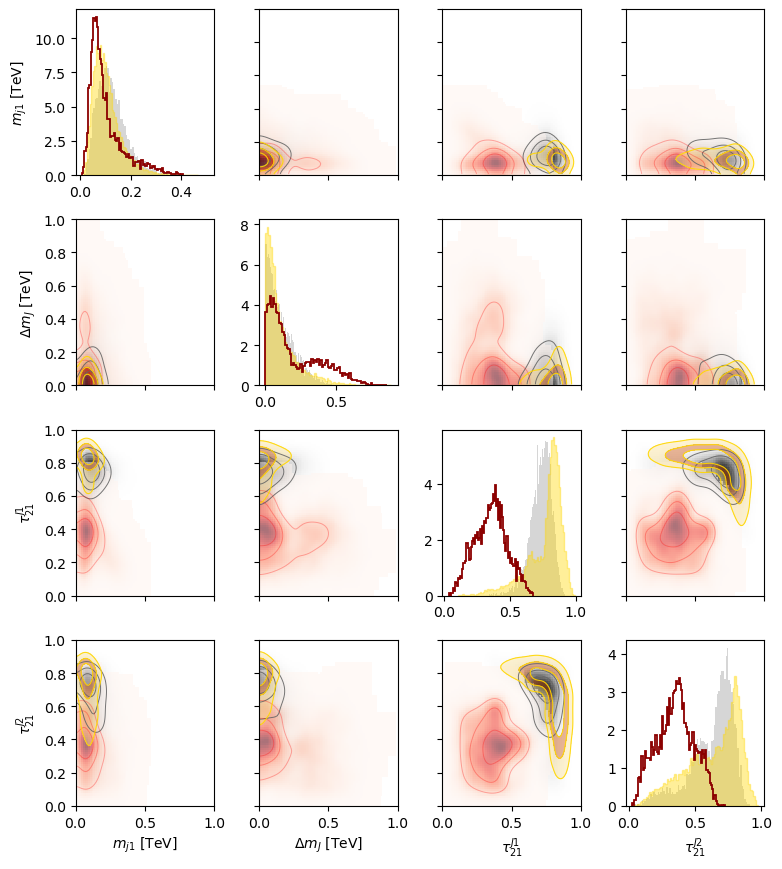

Saved: PNAS_plots/over_under_with_cluster0_overlay.png

Plotting cluster 1 overlay (n=325 points)...


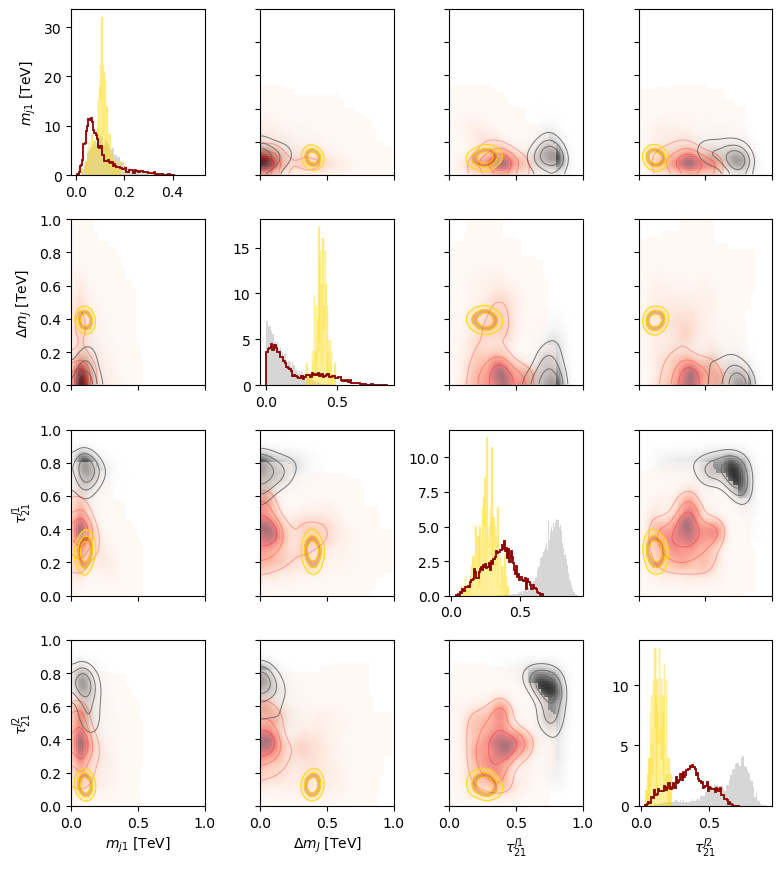

Saved: PNAS_plots/over_under_with_cluster1_overlay.png


In [ ]:
# Loop over all clusters and create separate overlay plots
for cid_overlay in range(len(y_clusters)):
    idx_overlay = y_clusters[cid_overlay]
    

    
    D_plot = X_over.shape[1]
    X_overlay = X_features[idx_overlay, :D_plot]
    
    print(f"\nPlotting cluster {cid_overlay} overlay (n={len(idx_overlay)} points)...")
    

    feature_names[2] = r"$\tau_{21}^{J1}$"
    feature_names[3] = r"$\tau_{21}^{J2}$"

    plot_scatter_matrix_over_under(
        X_over, col_over,
        X_under, col_under,
        feature_names=feature_names,
        sample=None,
        bins_diag=meta["bins_diag"],
        density_diag=meta["density_diag"],
        xlim=meta["xlim"],
        ylim=meta["ylim"],
        bins_offdiag=meta["bins_offdiag"],
        cmap_over=meta["cmap_over"],
        cmap_under=meta["cmap_under"],
        smooth_sigma_img=meta["smooth_sigma_img"],
        smooth_sigma_cnt=meta["smooth_sigma_cnt"],
        n_contours=meta["n_contours"],
        lognorm_offdiag=meta["lognorm_offdiag"],
        title=f"{meta['title']} Cluster {cid_overlay}",
        srb_over=meta["srb_over"],
        srb_under=meta["srb_under"],
        srb_true=srootb_results.get(cid_overlay, {}).get('S_sqrt_B', None),
        X_overlay=X_overlay,
        overlay_smooth_sigma=3.0,
        overlay_cmap="YlOrBr",
        # savepath=f"PNAS_plots/over_under_with_cluster{cid_overlay}_overlay.png",

    )
    
    print(f"Saved: PNAS_plots/over_under_with_cluster{cid_overlay}_overlay.png")

In [ ]:
import numpy as np
import utils_EE
import EagleEye as EagleEye

# --------------------------------------------------------
# Assumptions:
#   - refs = [bkg1, bkg2]
#   - Y    = data  (same as X_features_full in Fisher code)
#   - res_list[r] is the Soar result dict for refs[r] (do_IDE=True runs)
#   - y_clusters from Fisher partitioning (list of arrays of Y-indices)
#   - srootb_results from Fisher clusters: {cid: {'S', 'B', 'S_sqrt_B'}}
#   - p_ext, KM, quant defined
# --------------------------------------------------------

R  = len(refs)
Ny = Y.shape[0]

Z_partition = 10   # or whatever you used for per-bkg repechage

# Store detailed repechage info per reference
repechage_info_per_ref = []  # list of dicts, one per ref


for r_idx, Xr in enumerate(refs):
    print(f"\n=== Per-bkg repechage for ref {r_idx+1} ===")
    res_r = res_dicts[r_idx]

    Xr_arr = np.asarray(Xr, dtype=float)
    Y_arr  = np.asarray(Y, dtype=float)

    # Align dimensions defensively
    min_cols = min(Xr_arr.shape[1], Y_arr.shape[1])
    if Xr_arr.shape[1] != Y_arr.shape[1]:
        print(f"  Dim mismatch X_ref({Xr_arr.shape[1]}) vs Y({Y_arr.shape[1]}), truncating to {min_cols}")
    X_ref  = Xr_arr[:, :min_cols]
    Y_feat = Y_arr[:, :min_cols]

    # Partitioning
    clusters_plus, clusters_minus = utils_EE.partitioning_function(
        X_ref, Y_feat, res_r, p_ext=p_ext, Z=Z_partition
    )

    # Repechage
    rep_book = EagleEye.Repechage(
        X_ref, Y_feat, res_r,
        (clusters_plus, clusters_minus),
        p_ext=p_ext,
        quant=0,
    )

    # S/√B estimates per Y_OVER cluster
    est_dict = EagleEye.S_rootB_estimate_Y_overdensities(res_r, rep_book)
    srb_map  = est_dict.get('s/root(B)', {})

    print(f"  Found {len(rep_book.get('Y_OVER_clusters', {}))} Y_OVER repechage clusters. In bkg ref {r_idx+1}.")
    print(f"  S/√B estimates for clusters: {srb_map}")
    # Collect per-cluster info for this ref
    Y_over = rep_book.get('Y_OVER_clusters', {})
    clusters_info = []   # list of { 'key', 'idx', 'n', 's_est' }

    if isinstance(Y_over, dict):
        for key, info in Y_over.items():
            rep_list = info.get('Repechaged', [])
            if rep_list is None:
                rep_list = []
            try:
                idx_arr = np.asarray(rep_list, dtype=int)
            except Exception:
                idx_arr = np.array([], dtype=int)

            n_rep = idx_arr.size
            # try both string/int keys in srb_map
            s_est = srb_map.get(key, srb_map.get(int(key), None))

            clusters_info.append({
                'key'   : key,
                'idx'   : idx_arr,
                'n'     : n_rep,
                's_est' : s_est,
            })

    repechage_info_per_ref.append({
        'rep_book'      : rep_book,
        'srb_map'       : srb_map,
        'clusters_info' : clusters_info,
    })

# --------------------------------------------------------
# For each Fisher persistent cluster (y_clusters[cid]),
# and for each ref, find the repechage cluster with the
# LARGEST OVERLAP in Y-indices and report its ŝ(S/√B).
# --------------------------------------------------------

print("\n=== Best-overlap repechage clusters per Fisher cluster and ref ===")

for cid, idx_fisher in enumerate(y_clusters):
    idx_fisher = np.asarray(idx_fisher, dtype=int)
    n_fish = idx_fisher.size
    if n_fish == 0:
        continue

    srootb_true = srootb_results.get(cid, {}).get('S_sqrt_B', None)

    print(f"\nFisher cluster {cid}: n={n_fish}, S/√B_true={srootb_true}")

    for r_idx in range(R):
        info_r = repechage_info_per_ref[r_idx]
        clusters_info = info_r['clusters_info']

        best_key        = None
        best_overlap_n  = 0
        best_overlap_fr = 0.0
        best_s_est      = None

        for cinfo in clusters_info:
            idx_rep = cinfo['idx']
            if idx_rep.size == 0:
                continue

            overlap = np.intersect1d(idx_fisher, idx_rep)
            n_ovl   = overlap.size
            frac    = n_ovl / n_fish if n_fish > 0 else 0.0

            if n_ovl > best_overlap_n:
                best_overlap_n  = n_ovl
                best_overlap_fr = frac
                best_key        = cinfo['key']
                best_s_est      = cinfo['s_est']


        if best_key is None:
            print(f"  ref {r_idx+1}: no overlapping repechage clusters (all overlaps = 0)")
        else:
            print(
                f"  ref {r_idx+1}: best cluster {best_key} "
                f"(overlap={best_overlap_n}/{n_fish}, frac={best_overlap_fr:5.2f}), "
                f"ŝ(S/√B)={best_s_est}"
            )


=== Per-bkg repechage for ref 1 ===
-----------------------------------------------------------------
Clustering
-----------------------------------------------------------------
-----------------------------------------------------------------
Repêchage
-----------------------------------------------------------------


<IPython.core.display.Math object>

alpha = 1
alpha = 2


'DONE!'

<IPython.core.display.Math object>

...

'DONE!'

<IPython.core.display.Math object>

alpha = 1
alpha = 2


'DONE!'

  Found 2 Y_OVER repechage clusters. In bkg ref 2.
  S/√B estimates for clusters: {'Total': 266.43335994952537, 0: 266.4047101154675, 1: 4.00731370953346}

=== Best-overlap repechage clusters per Fisher cluster and ref ===

Fisher cluster 0: n=16883, S/√B_true=0.015393270840115785
  ref 1: best cluster 0 (overlap=4959/16883, frac= 0.29), ŝ(S/√B)=203.09953966663048
  ref 2: best cluster 0 (overlap=15668/16883, frac= 0.93), ŝ(S/√B)=266.4047101154675

Fisher cluster 1: n=325, S/√B_true=15.219604582129051
  ref 1: best cluster 1 (overlap=164/325, frac= 0.50), ŝ(S/√B)=25.988571889809595
  ref 2: best cluster 1 (overlap=8/325, frac= 0.02), ŝ(S/√B)=4.00731370953346


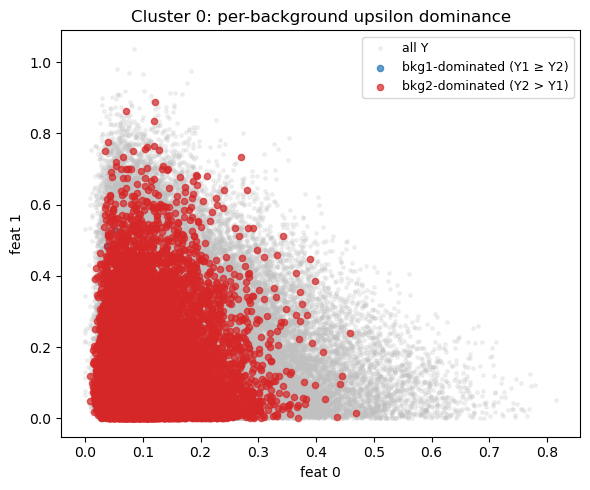

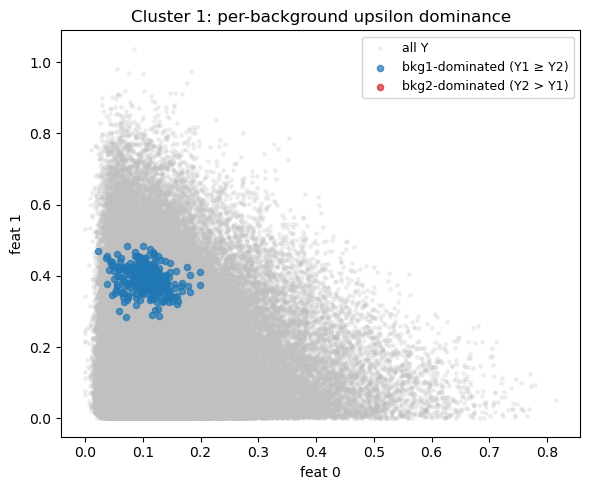

In [ ]:
# ============================================================
# === NEW: per-cluster 2D scatter showing bkg1 vs bkg2 role ===
# ============================================================

# Try to get per-background upsilons for Y:
ups1_all = None
ups2_all = None

if 'per_ref_ups' in globals():
    # expected shape ~ (R, Ny)
    ups_arr = np.asarray(per_ref_ups)
    if ups_arr.shape[0] >= 2:
        ups1_all = ups_arr[0]
        ups2_all = ups_arr[1]
elif 'res_list' in globals() and isinstance(res_list, (list, tuple)) and len(res_list) >= 2:
    ups1_all = np.asarray(res_list[0]['Upsilon_i_Y'])
    ups2_all = np.asarray(res_list[1]['Upsilon_i_Y'])

if (ups1_all is None) or (ups2_all is None):
    print("per_ref_ups / res_list with Upsilon_i_Y not found or incomplete: "
          "skipping per-background origin plots.")
else:
    # helper to plot one cluster
    def plot_cluster_origin(cid, idx):
        if idx.size == 0:
            return
        ups1 = np.asarray(ups1_all)[idx]
        ups2 = np.asarray(ups2_all)[idx]

        # label by which background gives larger upsilon
        mask_bkg2 = ups2 > ups1
        mask_bkg1 = ~mask_bkg2

        plt.figure(figsize=(6, 5))
        # background cloud
        plt.scatter(X_features[:, 0], X_features[:, 1],
                    c='silver', s=6, alpha=0.2, label='all Y')

        # cluster, split by dominance
        plt.scatter(X_features[idx[mask_bkg1], 0],
                    X_features[idx[mask_bkg1], 1],
                    c='C0', s=20, alpha=0.7, label='bkg1-dominated (Υ1 ≥ Υ2)')
        plt.scatter(X_features[idx[mask_bkg2], 0],
                    X_features[idx[mask_bkg2], 1],
                    c='C3', s=20, alpha=0.7, label='bkg2-dominated (Υ2 > Υ1)')

        plt.xlabel("feat 0")
        plt.ylabel("feat 1")
        plt.title(f"Cluster {cid}: per-background upsilon dominance")
        plt.legend(loc='best', fontsize=9)
        plt.tight_layout()
        # if you want to save:
        # if 'save_prefix' in globals():
        #     plt.savefig(f"{save_prefix}_cluster_{cid}_origin_bkg1_bkg2.png", dpi=150)
        plt.show()

    # cluster 1 origin plot
    cid = 0
    idx = y_clusters[cid]
    plot_cluster_origin(cid, idx)

    # cluster 0 origin plot
    cid = 1
    idx = y_clusters[cid]
    plot_cluster_origin(cid, idx)




=== Per-bkg repechage for ref 1 ===
-----------------------------------------------------------------
Clustering
-----------------------------------------------------------------
-----------------------------------------------------------------
Repêchage
-----------------------------------------------------------------


<IPython.core.display.Math object>

alpha = 1
alpha = 2


'DONE!'

<IPython.core.display.Math object>

...

'DONE!'

<IPython.core.display.Math object>

alpha = 1
alpha = 2


'DONE!'


=== Plotting best-overlap repechage clusters for Fisher cluster 1 ===
Fisher cluster 1: n=325, S/√B_true=15.219604582129051
  ref 1: best repechage cluster 1 (overlap=164/325, frac= 0.50), ŝ(S/√B)=25.988571889809595


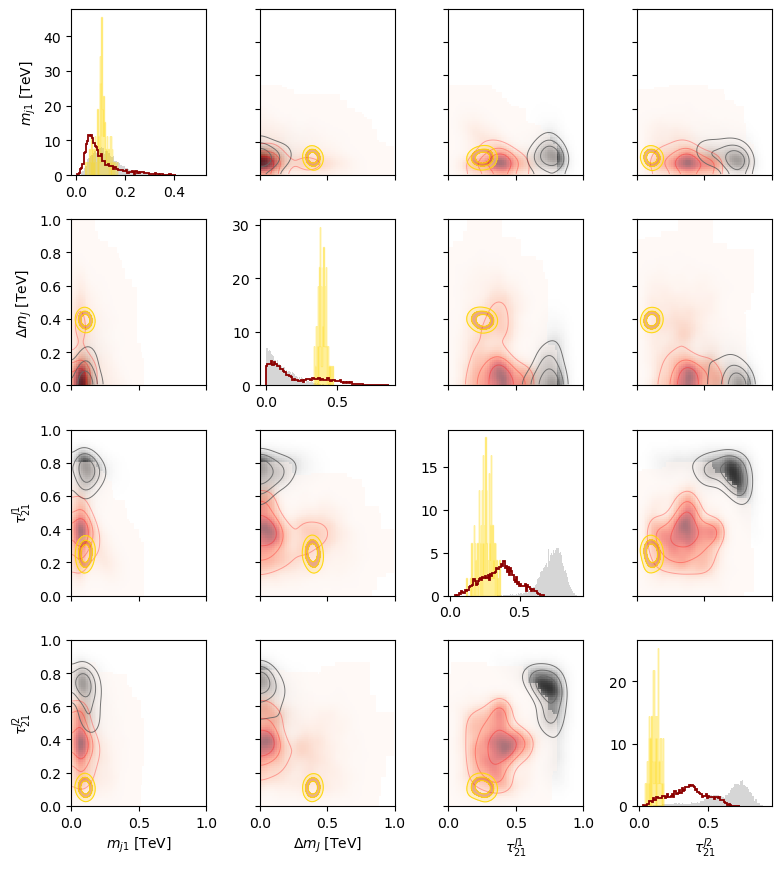

  ref 2: best repechage cluster 1 (overlap=8/325, frac= 0.02), ŝ(S/√B)=4.00731370953346


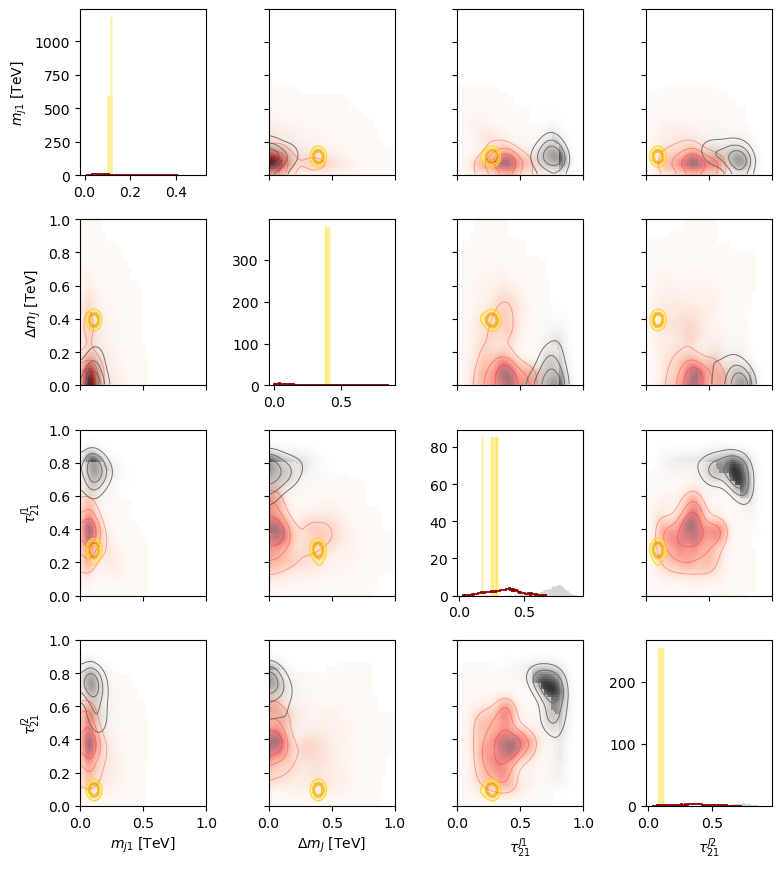

Mean ŝ(S/√B) over refs with estimates: 14.997942799671527


In [ ]:
import numpy as np
import utils_EE
import EagleEye as EagleEye

# --------------------------------------------------------
# Recompute / ensure per-bkg repechage info exists
# (clusters_info per reference with Y_OVER clusters)
# --------------------------------------------------------

R  = len(refs)
Y_arr_full = np.asarray(Y, dtype=float)

Z_partition = 5.65   # or whatever you used for per-bkg repechage

repechage_info_per_ref = []
best_s_est_list = []   # to store best ŝ(S/√B) per ref
for r_idx, Xr in enumerate(refs):
    print(f"\n=== Per-bkg repechage for ref {r_idx+1} ===")
    res_r = res_dicts[r_idx]

    Xr_arr = np.asarray(Xr, dtype=float)

    # Align dimensions defensively
    min_cols = min(Xr_arr.shape[1], Y_arr_full.shape[1])
    if Xr_arr.shape[1] != Y_arr_full.shape[1]:
        print(f"  Dim mismatch X_ref({Xr_arr.shape[1]}) vs Y({Y_arr_full.shape[1]}), truncating to {min_cols}")
    X_ref  = Xr_arr[:, :min_cols]
    Y_feat = Y_arr_full[:, :min_cols]

    # Partitioning
    clusters_plus, clusters_minus = utils_EE.partitioning_function(
        X_ref, Y_feat, res_r, p_ext=p_ext, Z=Z_partition
    )

    # Repechage
    rep_book = EagleEye.Repechage(
        X_ref, Y_feat, res_r,
        (clusters_plus, clusters_minus),
        p_ext=p_ext,
        quant=0,
    )

    # S/√B estimates per Y_OVER cluster
    est_dict = EagleEye.S_rootB_estimate_Y_overdensities(res_r, rep_book)
    srb_map  = est_dict.get('s/root(B)', {})

    # Collect per-cluster info for this ref
    Y_over = rep_book.get('Y_OVER_clusters', {})
    clusters_info = []   # list of { 'key', 'idx', 'n', 's_est' }

    if isinstance(Y_over, dict):
        for key, info in Y_over.items():
            rep_list = info.get('Repechaged', [])
            if rep_list is None:
                rep_list = []
            try:
                idx_arr = np.asarray(rep_list, dtype=int)
            except Exception:
                idx_arr = np.array([], dtype=int)

            n_rep = idx_arr.size
            # try both string/int keys in srb_map
            s_est = srb_map.get(key, srb_map.get(int(key), None))

            clusters_info.append({
                'key'   : key,
                'idx'   : idx_arr,
                'n'     : n_rep,
                's_est' : s_est,
            })

    repechage_info_per_ref.append({
        'rep_book'      : rep_book,
        'srb_map'       : srb_map,
        'clusters_info' : clusters_info,
    })

# --------------------------------------------------------
# Focus on persistent Fisher cluster 4
# --------------------------------------------------------

cid_target =1

if cid_target >= len(y_clusters):
    raise ValueError(f"Fisher cluster {cid_target} does not exist (len(y_clusters)={len(y_clusters)})")

idx_fisher = np.asarray(y_clusters[cid_target], dtype=int)
n_fish     = idx_fisher.size

if n_fish == 0:
    raise ValueError(f"Fisher cluster {cid_target} is empty.")

srootb_true = srootb_results.get(cid_target, {}).get('S_sqrt_B', None)
print(f"\n=== Plotting best-overlap repechage clusters for Fisher cluster {cid_target} ===")
print(f"Fisher cluster {cid_target}: n={n_fish}, S/√B_true={srootb_true}")

# We will plot one figure per ref (bkg1, bkg2), overlaying its best-overlap repechage cluster

for r_idx in range(R):
    info_r       = repechage_info_per_ref[r_idx]
    clusters_inf = info_r['clusters_info']

    best_key        = None
    best_idx_rep    = None
    best_overlap_n  = 0
    best_overlap_fr = 0.0
    best_s_est      = None

    for cinfo in clusters_inf:
        idx_rep = cinfo['idx']
        if idx_rep.size == 0:
            continue

        overlap = np.intersect1d(idx_fisher, idx_rep)
        n_ovl   = overlap.size
        frac    = n_ovl / n_fish if n_fish > 0 else 0.0

        if n_ovl > best_overlap_n:
            best_overlap_n  = n_ovl
            best_overlap_fr = frac
            best_key        = cinfo['key']
            best_idx_rep    = idx_rep
            best_s_est      = cinfo['s_est']

    if best_key is None or best_idx_rep is None:
        print(f"  ref {r_idx+1}: no overlapping repechage clusters (all overlaps = 0) -> skipping plot.")
        continue

    # store this ref's best estimate (if defined) for averaging later
    if best_s_est is not None:
        best_s_est_list.append(best_s_est)

    print(
        f"  ref {r_idx+1}: best repechage cluster {best_key} "
        f"(overlap={best_overlap_n}/{n_fish}, frac={best_overlap_fr:5.2f}), "
        f"ŝ(S/√B)={best_s_est}"
)

    # ----------------------------------------------------
    # Build overlay coordinates in the SAME feature space 
    # as your over/under plot (first D_plot dims).
    # ----------------------------------------------------
    D_plot        = X_over.shape[1]
    Y_feat_plot   = Y_arr_full[:, :D_plot]
    X_overlay_rep = Y_feat_plot[best_idx_rep]

    # ----------------------------------------------------
    # Plot: over/under + yellow overlay for this best cluster
    # ----------------------------------------------------
    title_here = (
        f"{meta['title']} | Fisher cluster {cid_target} vs ref {r_idx+1} "
        f"(rep cluster {best_key})"
    )



    plot_scatter_matrix_over_under(
        X_over, col_over,
        X_under, col_under,
        feature_names=feature_names,
        sample=None,
        bins_diag=meta["bins_diag"],
        density_diag=meta["density_diag"],
        xlim=meta["xlim"],
        ylim=meta["ylim"],
        bins_offdiag=meta["bins_offdiag"],
        cmap_over=meta["cmap_over"],
        cmap_under=meta["cmap_under"],
        smooth_sigma_img=meta["smooth_sigma_img"],
        smooth_sigma_cnt=meta["smooth_sigma_cnt"],
        n_contours=meta["n_contours"],
        lognorm_offdiag=meta["lognorm_offdiag"],
        title=title_here,
        srb_over=meta["srb_over"],
        srb_under=meta["srb_under"],
        srb_true=srootb_true,
        X_overlay=X_overlay_rep,
        overlay_smooth_sigma=3.0,
        overlay_cmap="YlOrBr",
        # Uncomment to save:
        # savepath=f"Paper_plots/over_under_Fisher4_ref{r_idx+1}_repcluster{best_key}.png",
    )
print("Mean ŝ(S/√B) over refs with estimates:",
      np.mean(best_s_est_list) if best_s_est_list else None)


After threshold 10.0: 314/325 points remain
Number of events above this threshold in cluster: 314


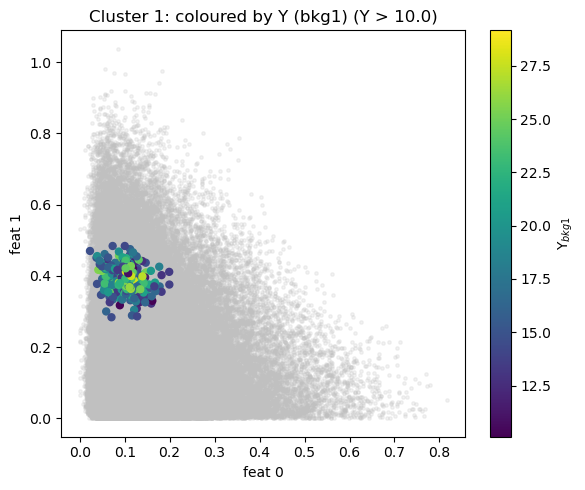

After threshold 6: 88/325 points remain
Number of events above this threshold in cluster: 88


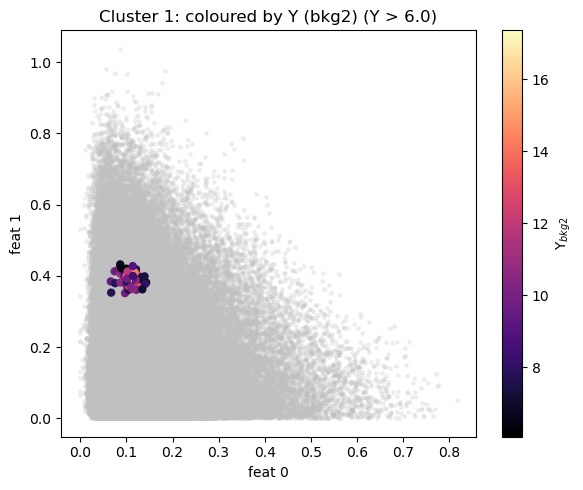

In [ ]:
def plot_cluster_coloured_by_bkg(cid, idx, bkg_idx=0, upsilon_threshold=None):
    """
    Plot cluster CID with colour = upsilon from specified background.
    
    Parameters:
    -----------
    cid : int
        Cluster ID
    idx : array
        Indices of points in the cluster
    bkg_idx : int
        Background index (0 for bkg1, 1 for bkg2)
    upsilon_threshold : float, optional
        If provided, only plot points with upsilon > threshold
    """
    if idx.size == 0:
        print(f"Cluster {cid} empty")
        return

    if 'per_ref_ups' not in globals():
        print("per_ref_ups not available")
        return
    
    ups_arr = np.asarray(per_ref_ups)
    if bkg_idx >= ups_arr.shape[0]:
        print(f"Background index {bkg_idx} out of range (max: {ups_arr.shape[0]-1})")
        return
    
    ups = ups_arr[bkg_idx][idx]
    
    # Apply threshold filter if specified
    if upsilon_threshold is not None:
        mask = ups > upsilon_threshold
        idx_filtered = idx[mask]
        ups_filtered = ups[mask]
        print(f"After threshold {upsilon_threshold}: {idx_filtered.size}/{idx.size} points remain")
        
        if idx_filtered.size == 0:
            print(f"No points above threshold {upsilon_threshold}")
            return
    else:
        idx_filtered = idx
        ups_filtered = ups

    plt.figure(figsize=(6,5))
    # grey background
    plt.scatter(X_features[:,0], X_features[:,1],
                c='silver', s=6, alpha=0.2)

    # cluster points coloured by upsilon
    cmap_choice = 'viridis' if bkg_idx == 0 else 'magma'
    sc = plt.scatter(X_features[idx_filtered,0], X_features[idx_filtered,1],
                     c=ups_filtered, cmap=cmap_choice, s=25)
    
    print("Number of events above this threshold in cluster:", idx_filtered.size)

    bkg_label = f"bkg{bkg_idx+1}"
    plt.colorbar(sc, label=rf'$\Upsilon_{{{bkg_label}}}$')
    plt.xlabel("feat 0")
    plt.ylabel("feat 1")
    title_str = f"Cluster {cid}: coloured by Υ ({bkg_label})"
    if upsilon_threshold is not None:
        title_str += f" (Υ > {upsilon_threshold:.1f})"
    plt.title(title_str)
    plt.tight_layout()
    plt.show()


# === call for cluster 1 with threshold ===
cid = 1
# Set your threshold (e.g., 10.0 or use a percentile)
threshold = 10.0  # or: np.percentile(ups1_all[y_clusters[cid]], 90)
plot_cluster_coloured_by_bkg(cid, y_clusters[cid], upsilon_threshold=threshold,bkg_idx=0)
plot_cluster_coloured_by_bkg(cid, y_clusters[cid], upsilon_threshold=6,bkg_idx=1)

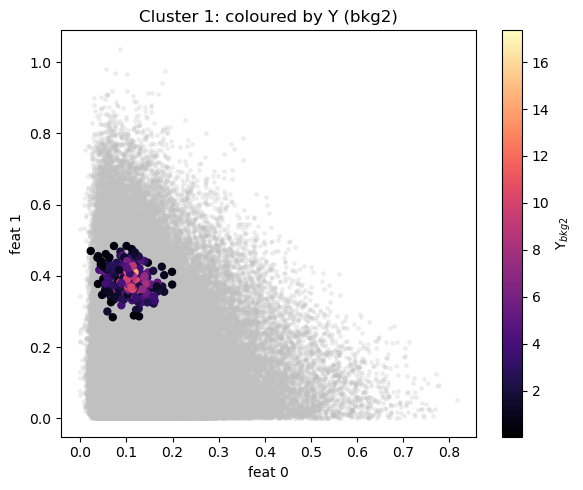

In [ ]:
def plot_cluster_coloured_by_bkg2(cid, idx):
    """
    Plot cluster CID with colour = upsilon from background 2 (ups2_all).
    """
    if idx.size == 0:
        print(f"Cluster {cid} empty")
        return

    if ups2_all is None:
        print("ups2_all not available")
        return

    ups2 = np.asarray(ups2_all)[idx]

    plt.figure(figsize=(6,5))
    # grey background
    plt.scatter(X_features[:,0], X_features[:,1],
                c='silver', s=6, alpha=0.2)

    # cluster points coloured by ups2
    sc = plt.scatter(X_features[idx,0], X_features[idx,1],
                     c=ups2, cmap='magma', s=25)

    plt.colorbar(sc, label=r'$\Upsilon_{bkg2}$')
    plt.xlabel("feat 0")
    plt.ylabel("feat 1")
    plt.title(f"Cluster {cid}: coloured by Υ (bkg2)")
    plt.tight_layout()
    plt.show()


# === call for clusters 0 and 1 ===
cid = 1; plot_cluster_coloured_by_bkg2(cid, y_clusters[cid])